**Import moddules**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

print('Done importing modules...')

Done importing modules...


In [8]:
# create df
file_path = r'../data/Python_Diwali_Sales_Analysis/Diwali Sales Data.csv'

df = pd.read_csv(file_path, encoding='unicode_escape')

print('Done creating dataframe...')

Done creating dataframe...


In [9]:
# to prevent alteration
df_copy = df.copy()

# drop status and unnamed1 columns
df_copy = df_copy.drop(columns=['Status', 'unnamed1'])
print('Successfully dropped columns... \n')

# display df copy's metadata
display(df_copy.info())

Successfully dropped columns... 

<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), str(8)
memory usage: 1.1 MB


None

**Remarks**

This section contains the bivariate analysis, customer segmentation, and conclusion for the overall sales analysis. To ensure data quality, duplicate records were removed, and missing values in the `Amount` column were handled using median imputation.

In [10]:
# remove duplicates
df_copy = df_copy.drop_duplicates()
print('Successfully dropped duplicates in the dataframe copy... \n')

# display update
print(f'\nRows after removing duplicates: {len(df_copy)}')
print(f'Remaining duplicate rows: {df_copy.duplicated().sum()}')

Successfully dropped duplicates in the dataframe copy... 


Rows after removing duplicates: 11243
Remaining duplicate rows: 0


In [11]:
category_medians = df_copy.groupby('Product_Category')['Amount'].median()


display(
    category_medians.loc[
        ['Auto', 'Footwear & Shoes', 'Furniture', 'Food']
    ]
)


# perform imputation on missing values
df_copy['Amount'] = df_copy['Amount'].fillna(
    df_copy['Product_Category'].map(category_medians)
)

print('Missing Amount values after imputation:')
print(df_copy['Amount'].isnull().sum())

Product_Category
Auto               19,287.50
Footwear & Shoes   16,289.00
Furniture          16,277.50
Food               15,232.00
Name: Amount, dtype: float64

Missing Amount values after imputation:
0


**Bivariate Analysis: Marital Status vs Numerical Columns**

Marital_Status
0    6518
1    4725
Name: count, dtype: int64
Marital_Status
0   57.97
1   42.03
Name: proportion, dtype: float64 



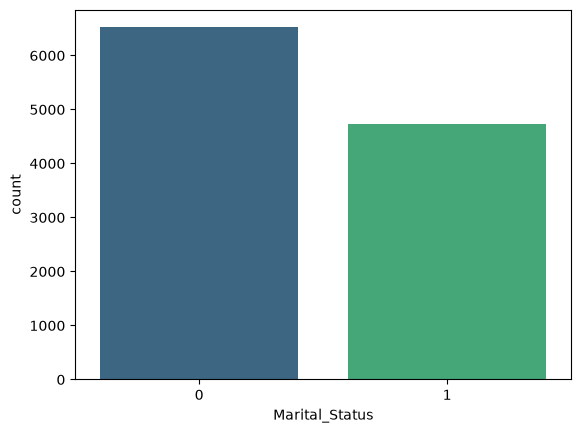

In [17]:
# inspect binary column
print(df_copy['Marital_Status'].value_counts())
print("=====" * 10)
print(df_copy['Marital_Status'].value_counts(normalize=True).mul(100), '\n')

sns.countplot(
    data=df_copy,
    x='Marital_Status',
    palette='viridis'
)

plt.show()

In [18]:
# Marital Status vs Numerical Columns
num_cols = [
    'Amount',
    'Orders',
    'Age'
]

for col in num_cols:
  num_by_marital = df_copy.groupby('Marital_Status')[col].agg(['sum', 'mean'])
  print(f'{col} by Marital Status: ')
  print(num_by_marital)
  print("=====" * 10)

  num_by_marital_pct = df_copy.groupby('Marital_Status')[col].sum().div(df_copy[col].sum()).mul(100).round(2)

  print(f'{col} percentage by Marital Status: ')
  print(num_by_marital_pct)
  print("=====" * 10, '\n')

Amount by Marital Status: 
                         sum     mean
Marital_Status                       
0              62,165,833.94 9,537.56
1              44,214,275.49 9,357.52
Amount percentage by Marital Status: 
Marital_Status
0   58.44
1   41.56
Name: Amount, dtype: float64

Orders by Marital Status: 
                  sum  mean
Marital_Status             
0               16243  2.49
1               11738  2.48
Orders percentage by Marital Status: 
Marital_Status
0   58.05
1   41.95
Name: Orders, dtype: float64

Age by Marital Status: 
                   sum  mean
Marital_Status              
0               231766 35.56
1               166493 35.24
Age percentage by Marital Status: 
Marital_Status
0   58.19
1   41.81
Name: Age, dtype: float64



**Interpretation:**

The dataset contains more unmarried customers than married customers, with **6,518 unmarried customers (57.97%)** and **4,725 married customers (42.03%)**.

The unmarried group accounts for **58.44% of total Amount**, while the married group accounts for **41.56%**. The average Amount is also slightly higher among unmarried customers at **9,537.56**, compared with **9,357.52** for married customers. This indicates that unmarried customers contribute a larger share of total spending and have a slightly higher average spending amount per record.

For Orders, unmarried customers account for **58.05% of total orders**, compared with **41.95%** for married customers. However, their average number of orders is nearly identical, at **2.49 for unmarried customers** and **2.48 for married customers**. This suggests that the higher total number of orders from unmarried customers is largely associated with their larger representation in the dataset rather than a meaningful difference in average order frequency.

For Age, the average ages are also very similar between the two groups. Unmarried customers have an average age of **35.56**, while married customers have an average age of **35.24**. This indicates that there is little difference in average age between the two marital-status groups.

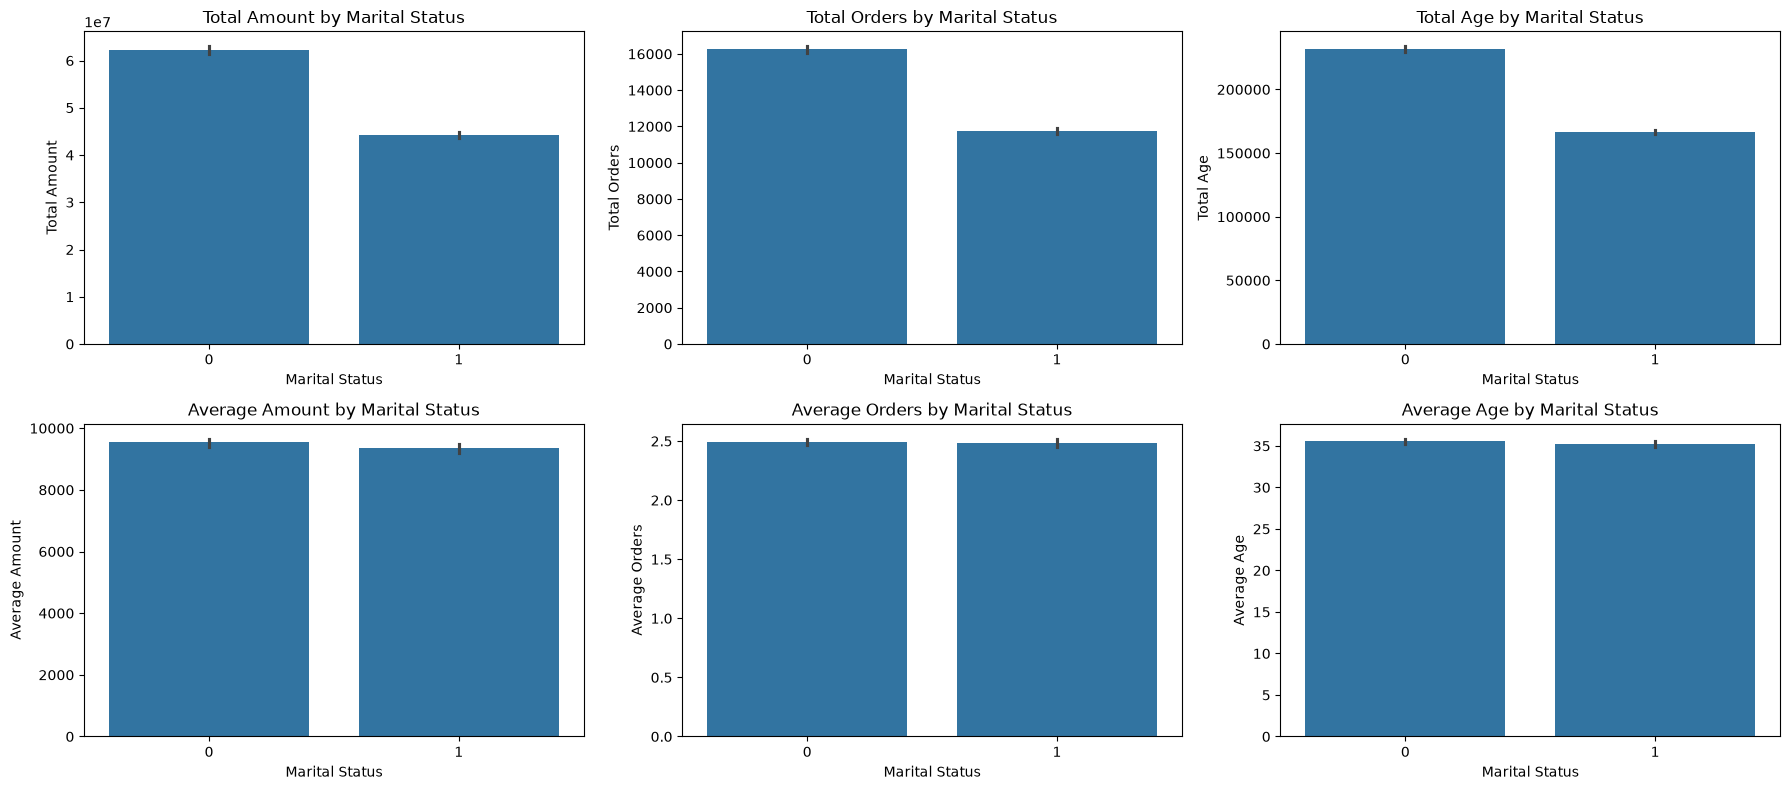

In [19]:
# plot num cols by marital status

num_cols= [
    'Amount',
    'Orders',
    'Age'
]

fig, axes = plt.subplots(
    2,3,
    figsize=(18,8)
)

for i, col in enumerate(num_cols):

  # total chart
  sns.barplot(
      data=df_copy,
      x='Marital_Status',
      y=col,
      estimator='sum',
      ax=axes[0, i]
  )

  axes[0, i].set_title(f'Total {col} by Marital Status')
  axes[0, i].set_xlabel('Marital Status')
  axes[0, i].set_ylabel(f'Total {col}')

  # average chart
  sns.barplot(
      data=df_copy,
      x='Marital_Status',
      y=col,
      estimator='mean',
      ax=axes[1, i]
  )

  axes[1, i].set_title(f'Average {col} by Marital Status')
  axes[1, i].set_xlabel('Marital Status')
  axes[1, i].set_ylabel(f'Average {col}')


plt.tight_layout()
plt.show()

**Bivariate Analysis: Marital Status vs. Categorical Columns**

In [21]:
cat_cols = (
    df_copy.select_dtypes(include='object')
    .drop(columns=['Cust_name', 'Product_ID'])
    .columns
    .tolist()
)

for col in cat_cols:

    # Count
    marital_cat = df_copy[['Marital_Status', col]].value_counts()

    # Percentage within each marital status
    marital_cat_pct = pd.crosstab(
        df_copy['Marital_Status'],
        df_copy[col],
        normalize='index'
    ).mul(100).round(2)

    print(f'{col} by Marital Status:')
    print(marital_cat)
    print()

    print(f'{col} percentage by Marital Status:')
    print(marital_cat_pct)
    print('=' * 50)

Gender by Marital Status:
Marital_Status  Gender
0               F         4575
1               F         3263
0               M         1943
1               M         1462
Name: count, dtype: int64

Gender percentage by Marital Status:
Gender             F     M
Marital_Status            
0              70.19 29.81
1              69.06 30.94
Age Group by Marital Status:
Marital_Status  Age Group
0               26-35        2608
1               26-35        1930
0               36-45        1318
                18-25        1077
1               36-45         967
                18-25         801
0               46-50         577
                51-55         495
1               46-50         410
                51-55         336
0               55+           259
                0-17          184
1               55+           169
                0-17          112
Name: count, dtype: int64

Age Group percentage by Marital Status:
Age Group       0-17  18-25  26-35  36-45  46-50  51-55  

**Interpretation:**

- Both unmarried and married customers are predominantly female, with females accounting for 70.19% of unmarried customers and 69.06% of married customers. The similar proportions indicate little difference in gender composition between the two marital-status groups.

- The 26–35 age group is the largest segment for both unmarried and married customers, accounting for 40.01% and 40.85%, respectively. The distributions across the remaining age groups are also similar, suggesting that marital status does not substantially differentiate the age-group composition of the dataset.

- Uttar Pradesh has the largest share of customers in both marital-status groups, accounting for 17.18% of unmarried customers and 17.44% of married customers. Maharashtra, Karnataka, Delhi, and Madhya Pradesh also represent relatively large portions of both groups. Overall, the state distributions are highly similar, indicating limited differentiation between married and unmarried customers based on geographic location.

- The Central zone represents the largest share of both unmarried and married customers, accounting for 38.05% and 38.39%, respectively. The Southern zone is the second-largest for both groups. The relatively small differences across zones indicate that the geographic distribution is broadly similar regardless of marital status.

- The occupational composition shows greater differences between marital-status groups compared with gender, age group, state, and zone. Healthcare accounts for 15.56% of unmarried customers but only 8.34% of married customers. In contrast, IT Sector and Banking represent larger shares among married customers, at 15.22% and 12.04%, respectively. This suggests that occupation may provide more differentiation between marital-status groups and could be worth investigating further for customer segmentation.

- Clothing & Apparel is the largest product category for both unmarried and married customers, accounting for 23.52% and 23.70%, respectively. Food represents a larger share among unmarried customers (23.03%), while Electronics & Gadgets represents a larger share among married customers (19.26%). Overall, however, the product-category distributions are relatively similar between the two groups.

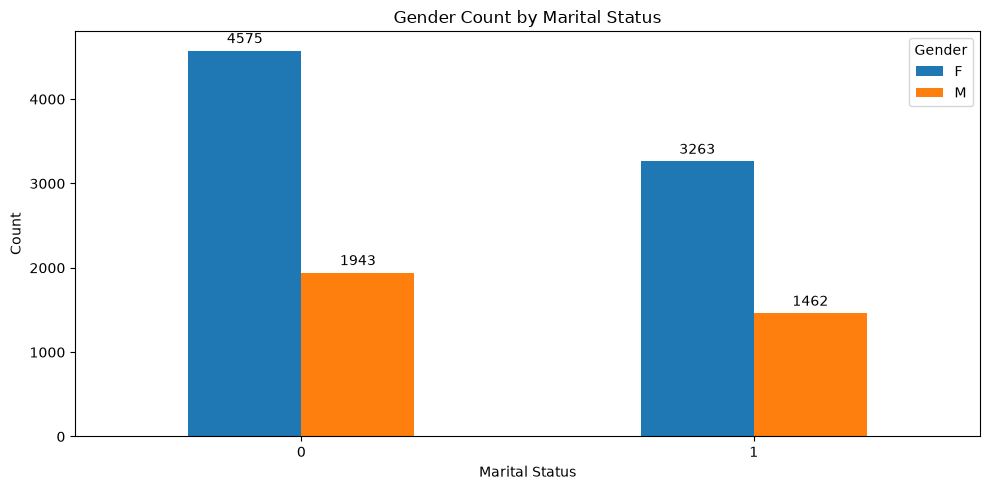

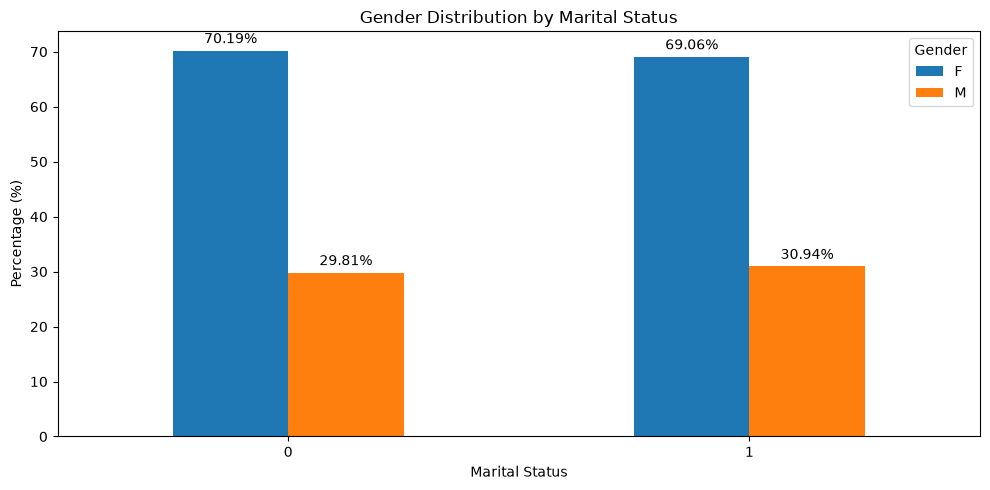

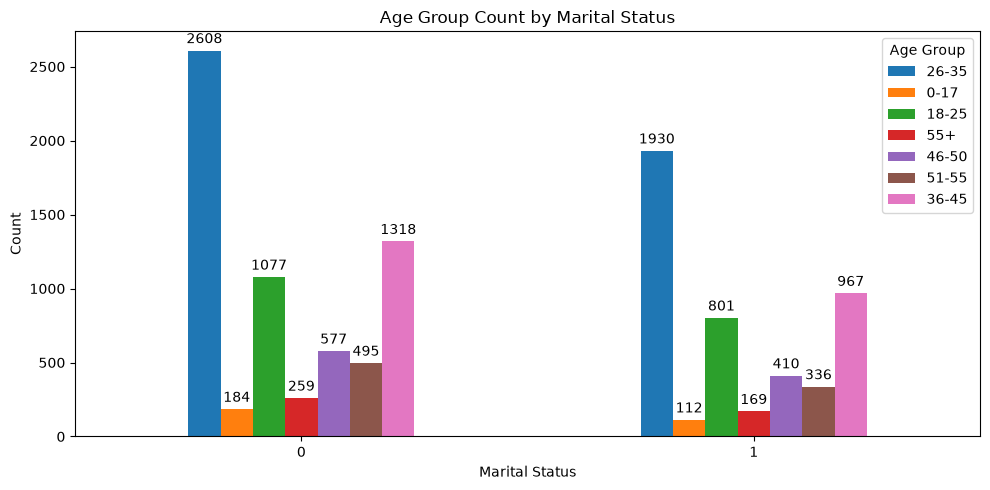

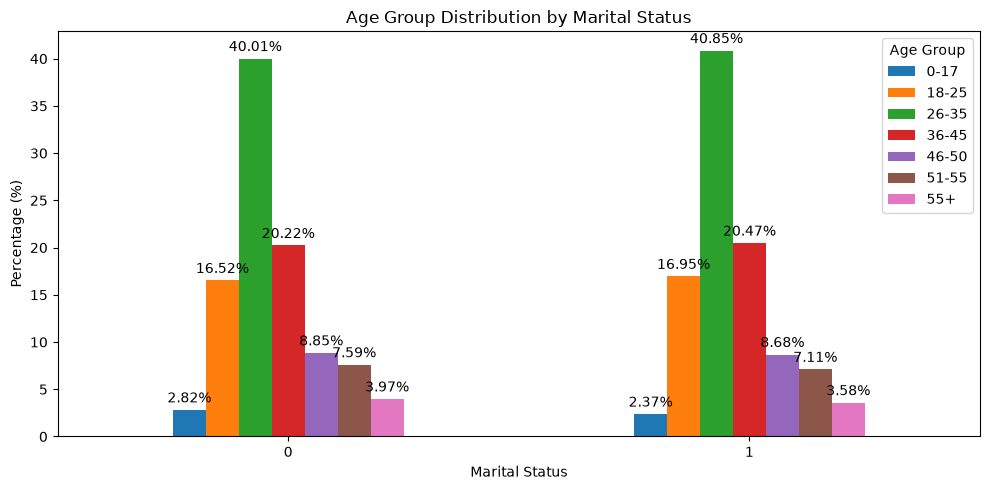

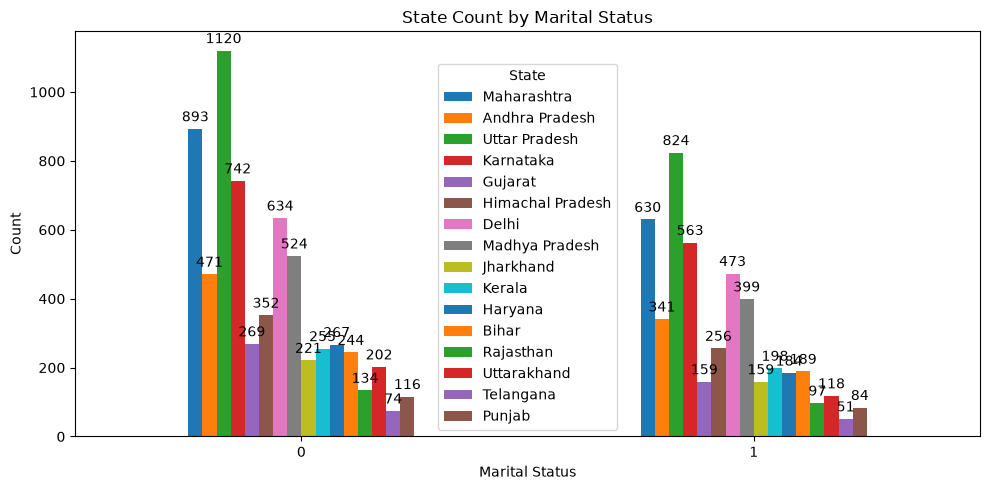

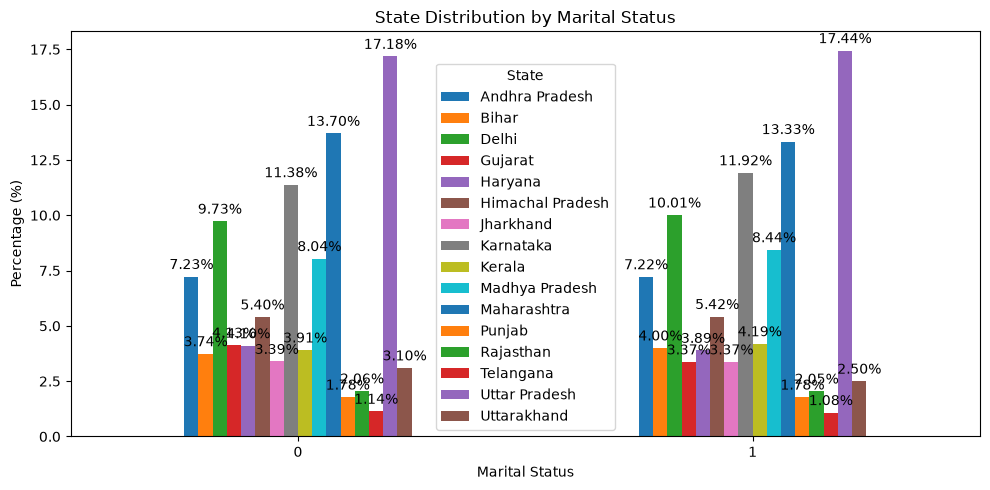

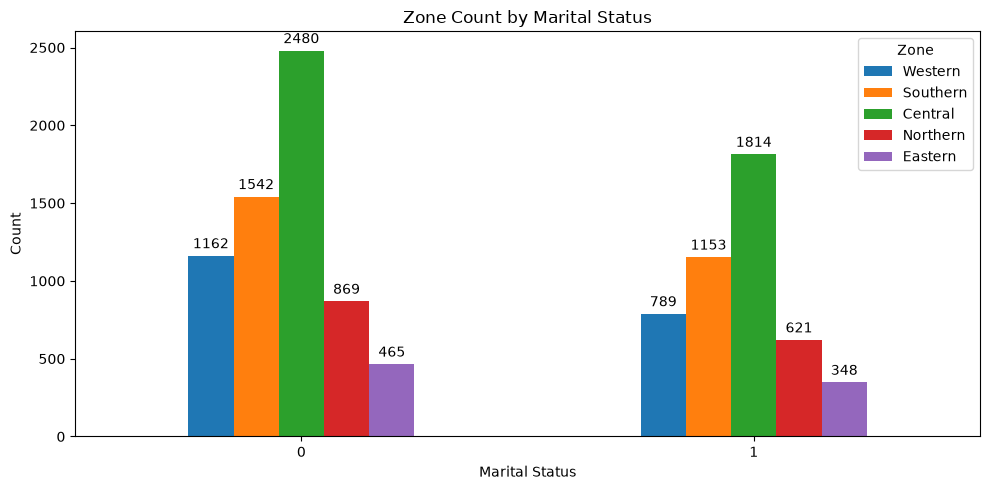

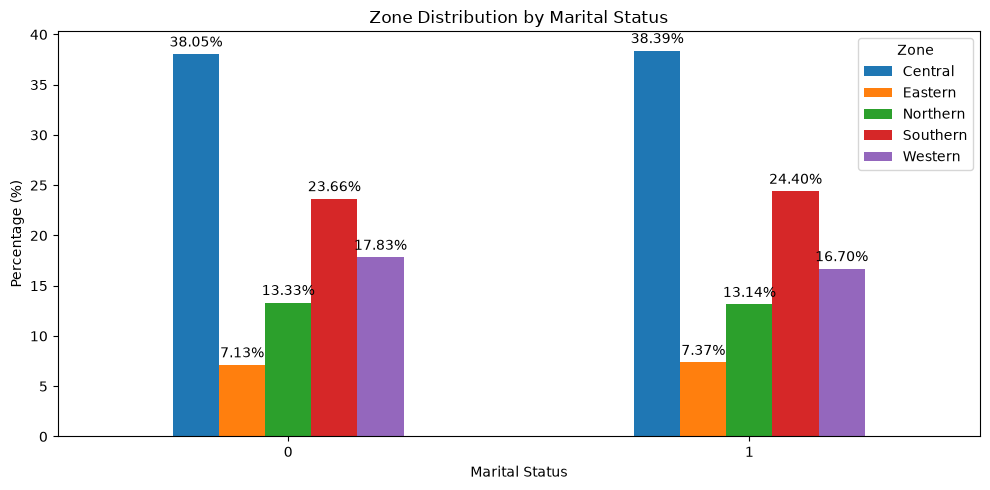

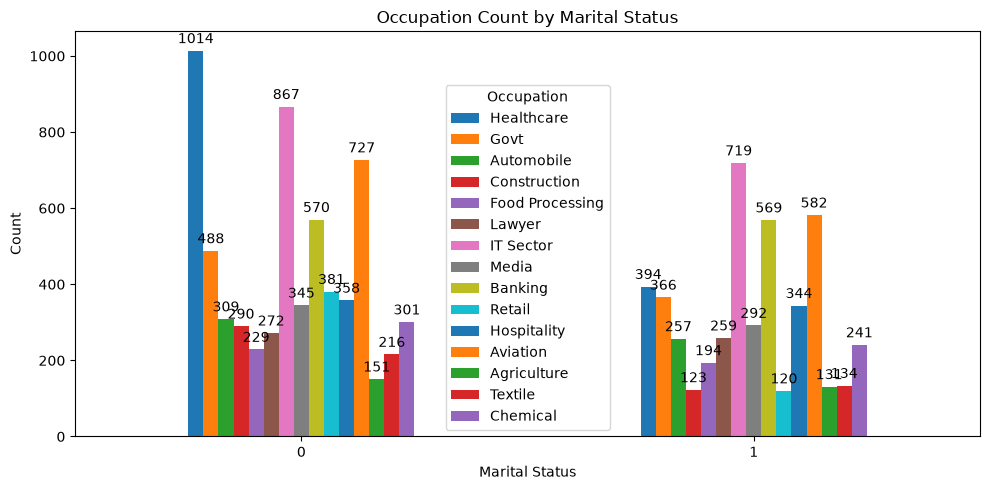

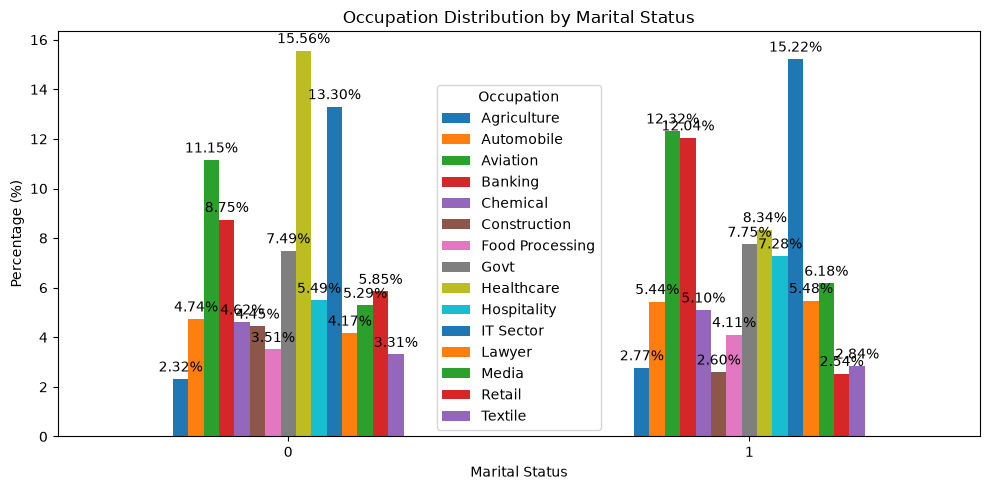

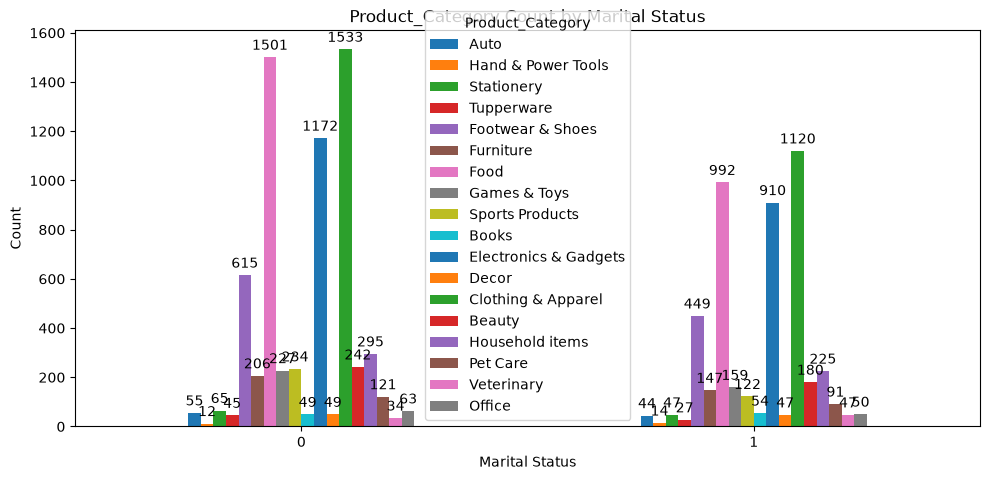

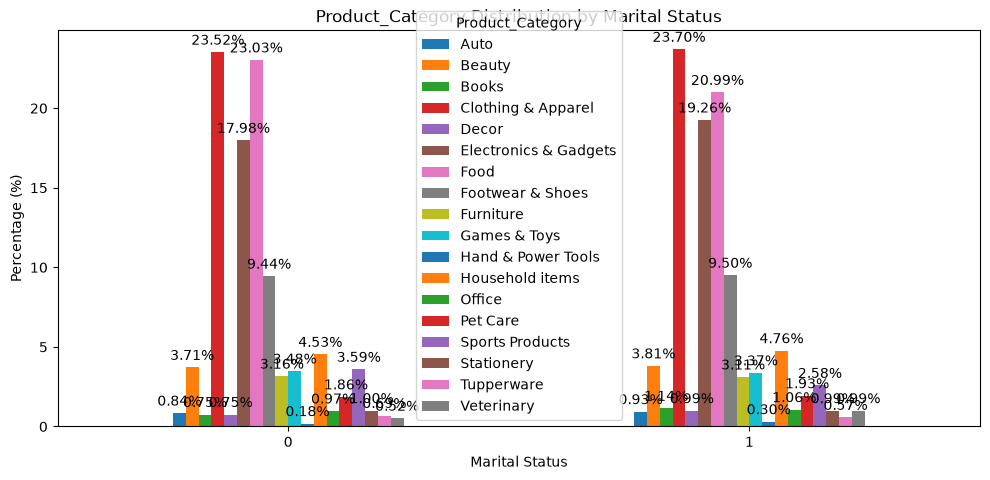

In [22]:
for col in cat_cols:

    # Count
    marital_cat = df_copy[['Marital_Status', col]].value_counts()

    # Percentage within each marital status
    marital_cat_pct = pd.crosstab(
        df_copy['Marital_Status'],
        df_copy[col],
        normalize='index'
    ).mul(100).round(2)

    # Count plot
    ax = marital_cat.unstack().plot(
        kind='bar',
        figsize=(10, 5)
    )

    plt.title(f'{col} Count by Marital Status')
    plt.xlabel('Marital Status')
    plt.ylabel('Count')
    plt.legend(title=col)
    plt.xticks(rotation=0)

    for container in ax.containers:
        ax.bar_label(container, padding=3)

    plt.tight_layout()
    plt.show()


    # Percentage plot
    ax = marital_cat_pct.plot(
        kind='bar',
        figsize=(10, 5)
    )

    plt.title(f'{col} Distribution by Marital Status')
    plt.xlabel('Marital Status')
    plt.ylabel('Percentage (%)')
    plt.legend(title=col)

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.2f%%',
            padding=3
        )

    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

**Bivariate Analysis: Gender vs Numerical Columns**

In [23]:
# Gender vs Numerical Columns
num_cols = [
    'Amount',
    'Orders',
    'Age'
]

for col in num_cols:
    num_by_gender = df_copy.groupby('Gender')[col].agg(['sum', 'mean'])
    
    print(f'{col} by Gender:')
    print(num_by_gender)
    print("=====" * 10)

    num_by_gender_pct = (
        df_copy.groupby('Gender')[col]
        .sum()
        .div(df_copy[col].sum())
        .mul(100)
        .round(2)
    )

    print(f'{col} percentage by Gender:')
    print(num_by_gender_pct)
    print("=====" * 10, '\n')

Amount by Gender:
                 sum     mean
Gender                       
F      74,473,386.93 9,501.58
M      31,906,722.50 9,370.55
Amount percentage by Gender:
Gender
F   70.01
M   29.99
Name: Amount, dtype: float64

Orders by Gender:
          sum  mean
Gender             
F       19554  2.49
M        8427  2.47
Orders percentage by Gender:
Gender
F   69.88
M   30.12
Name: Orders, dtype: float64

Age by Gender:
           sum  mean
Gender              
F       276985 35.34
M       121274 35.62
Age percentage by Gender:
Gender
F   69.55
M   30.45
Name: Age, dtype: float64



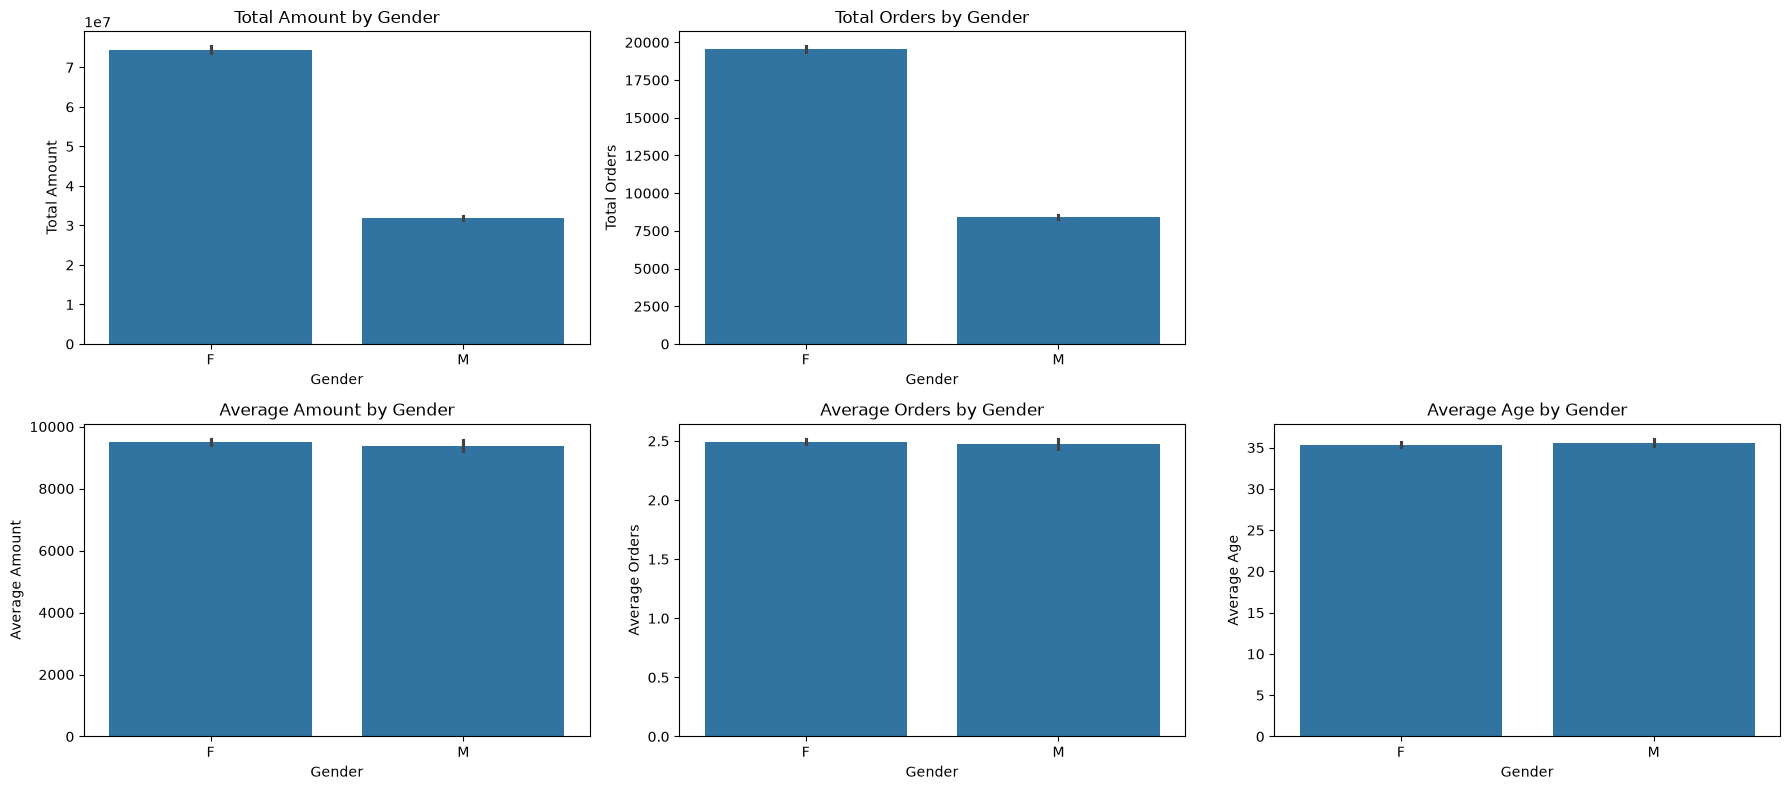

In [24]:
# Plot numerical columns by Gender

sum_cols = [
    'Amount',
    'Orders'
]

mean_cols = [
    'Amount',
    'Orders',
    'Age'
]

fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 8)
)

# Total charts
for i, col in enumerate(sum_cols):

    sns.barplot(
        data=df_copy,
        x='Gender',
        y=col,
        estimator='sum',
        ax=axes[0, i]
    )

    axes[0, i].set_title(f'Total {col} by Gender')
    axes[0, i].set_xlabel('Gender')
    axes[0, i].set_ylabel(f'Total {col}')


# Average charts
for i, col in enumerate(mean_cols):

    sns.barplot(
        data=df_copy,
        x='Gender',
        y=col,
        estimator='mean',
        ax=axes[1, i]
    )

    axes[1, i].set_title(f'Average {col} by Gender')
    axes[1, i].set_xlabel('Gender')
    axes[1, i].set_ylabel(f'Average {col}')


# Remove the unused top-right subplot
fig.delaxes(axes[0, 2])

plt.tight_layout()
plt.show()

**Bivariate Analysis: Gender vs Categorical Columns**

In [25]:
cat_cols_no_gender = [
    'Age Group',
    'Occupation',
    'State',
    'Zone',
    'Product_Category'
]

for col in cat_cols_no_gender:

    # Count
    gender_cat = df_copy[['Gender', col]].value_counts()

    # Percentage within each gender
    gender_cat_pct = pd.crosstab(
        df_copy['Gender'],
        df_copy[col],
        normalize='index'
    ).mul(100).round(2)

    print(f'{col} by Gender:')
    print(gender_cat)
    print()

    print(f'{col} percentage by Gender:')
    print(gender_cat_pct)
    print('=' * 50)

Age Group by Gender:
Gender  Age Group
F       26-35        3268
        36-45        1580
        18-25        1305
M       26-35        1270
        36-45         705
F       46-50         696
M       18-25         573
F       51-55         554
M       46-50         291
        51-55         277
F       55+           273
        0-17          162
M       55+           155
        0-17          134
Name: count, dtype: int64

Age Group percentage by Gender:
Age Group  0-17  18-25  26-35  36-45  46-50  51-55  55+
Gender                                                 
F          2.07  16.65  41.69  20.16   8.88   7.07 3.48
M          3.94  16.83  37.30  20.70   8.55   8.14 4.55
Occupation by Gender:
Gender  Occupation     
F       IT Sector          1075
        Healthcare          968
        Aviation            931
        Banking             825
        Govt                605
M       IT Sector           511
F       Hospitality         468
M       Healthcare          440
F       Medi

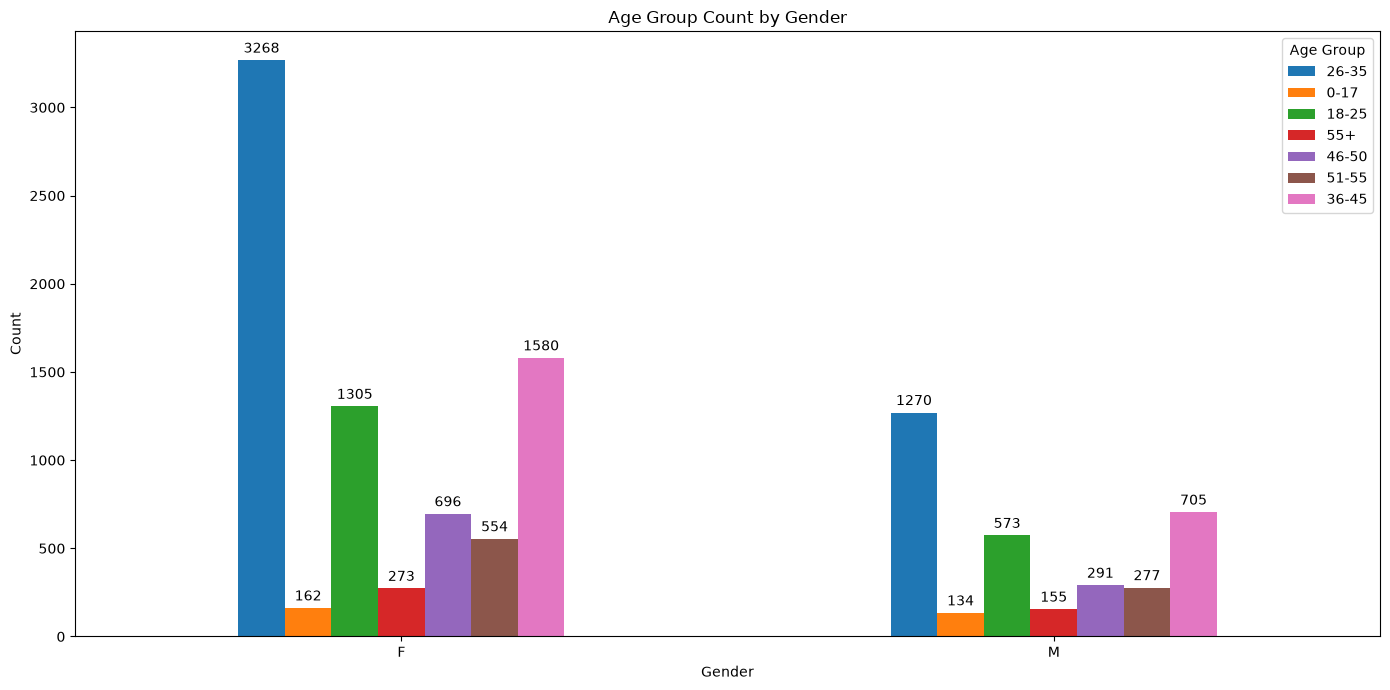

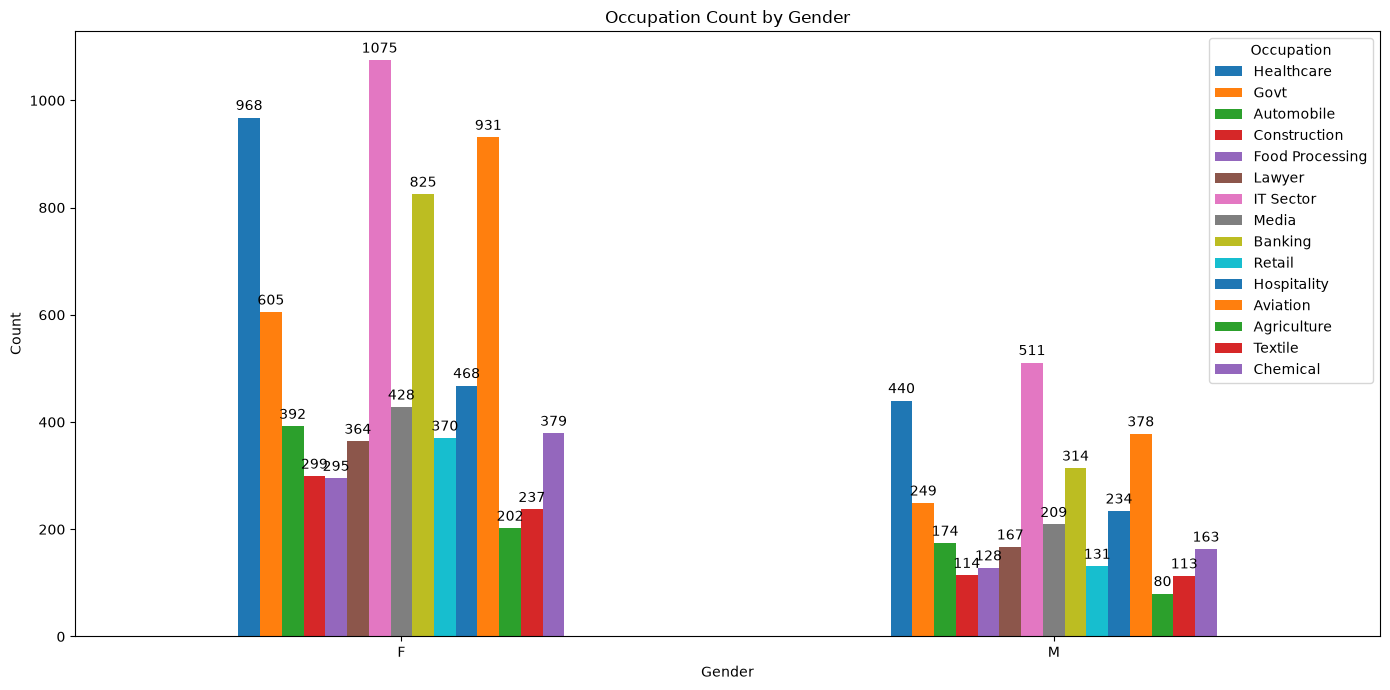

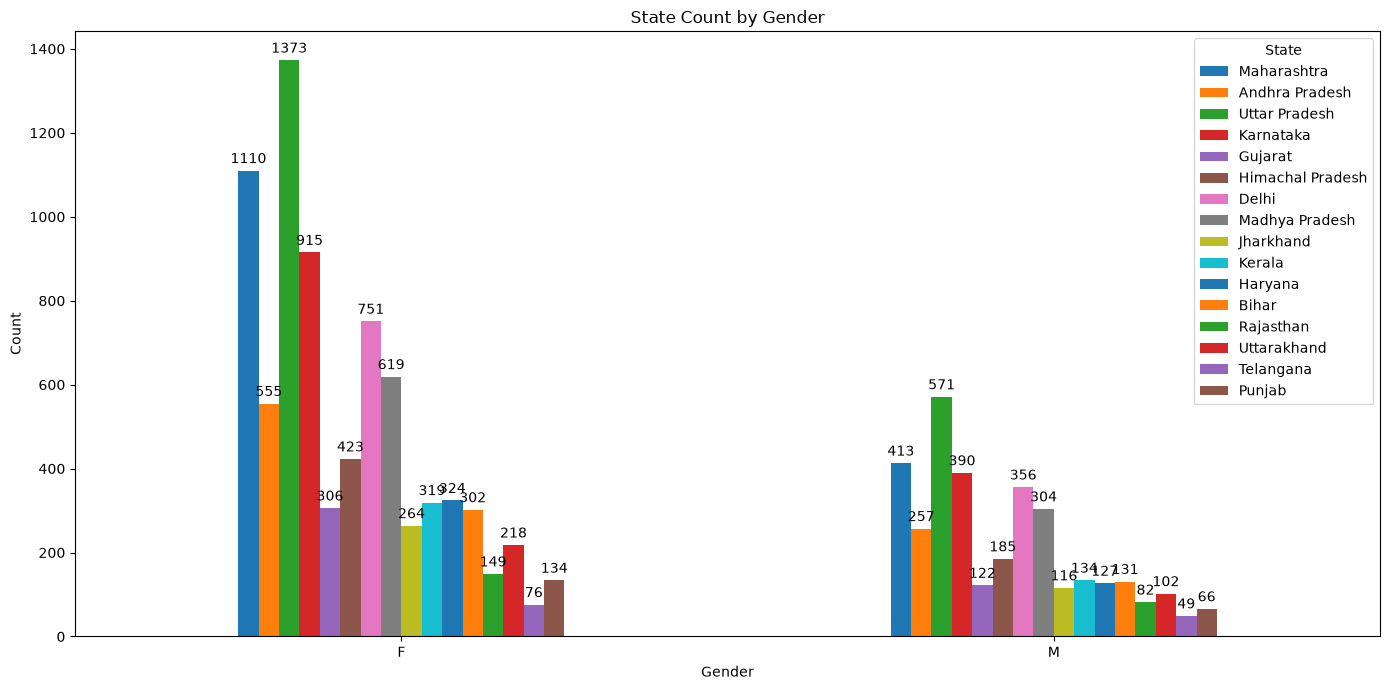

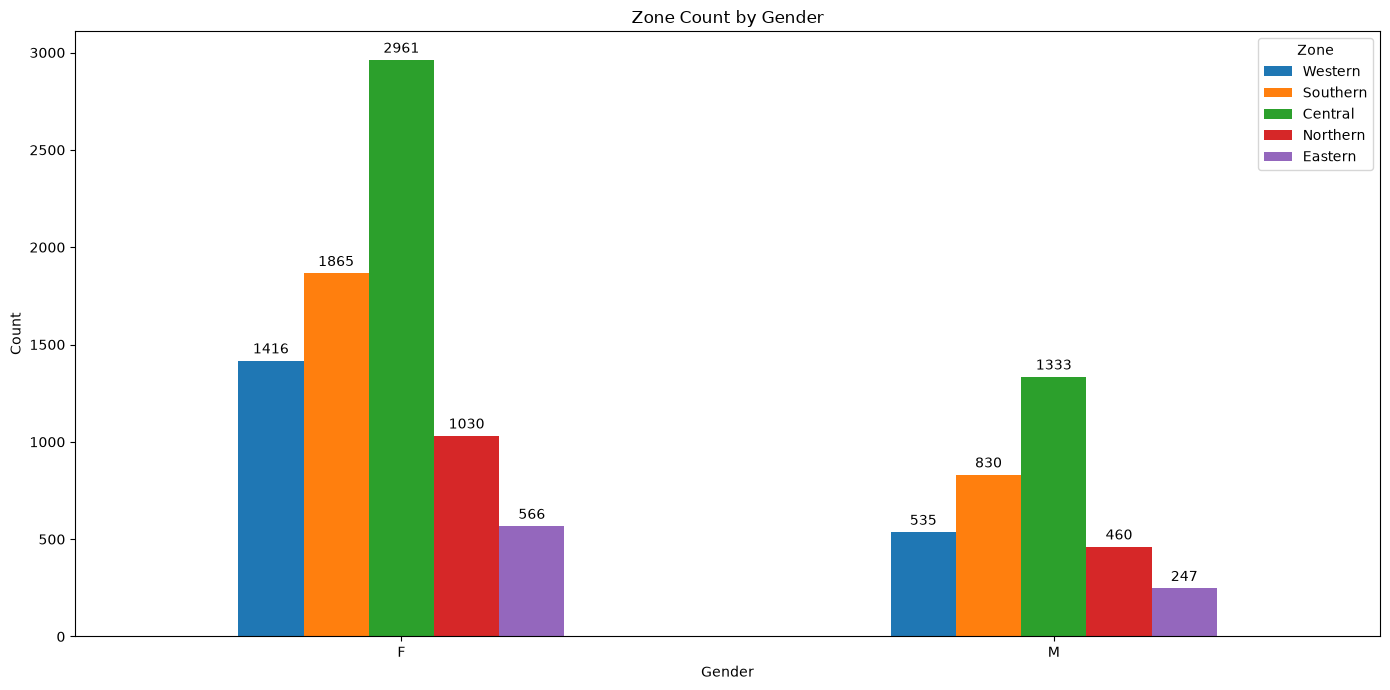

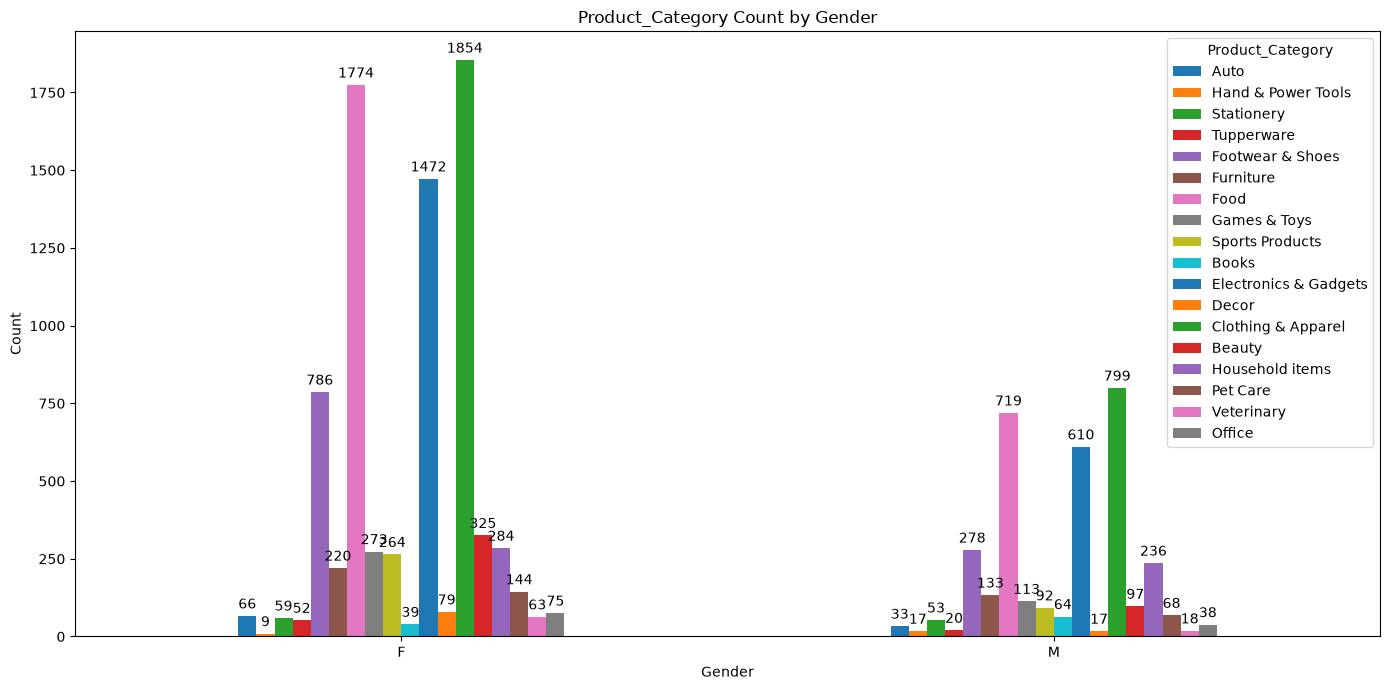

In [26]:
for col in cat_cols_no_gender:

    # Count
    gender_cat = df_copy[['Gender', col]].value_counts()

    # Percentage within each marital status
    gender_cat_pct = pd.crosstab(
        df_copy['Gender'],
        df_copy[col],
        normalize='index'
    ).mul(100).round(2)

    # Count plot
    ax = gender_cat.unstack().plot(
        kind='bar',
        figsize=(14, 7)
    )

    plt.title(f'{col} Count by Gender')
    plt.xlabel('Gender')
    plt.ylabel('Count')
    plt.legend(title=col)
    plt.xticks(rotation=0)

    for container in ax.containers:
        ax.bar_label(container, padding=3)

    plt.tight_layout()
    plt.show()

**Bivariate Analysis: Age Group vs Numerical Columns**

In [27]:
for col in num_cols:
    num_by_age_group = df_copy.groupby('Age Group')[col].agg(['sum', 'mean'])

    print(f'{col} by Age Group:')
    print(num_by_age_group)
    print("=====" * 10)

    num_by_age_group_pct = (
        df_copy.groupby('Age Group')[col]
        .sum()
        .div(df_copy[col].sum())
        .mul(100)
        .round(2)
    )

    print(f'{col} percentage by Age Group:')
    print(num_by_age_group_pct)
    print("=====" * 10, '\n')

Amount by Age Group:
                    sum     mean
Age Group                       
0-17       2,699,653.00 9,120.45
18-25     17,235,530.00 9,177.60
26-35     42,613,278.44 9,390.32
36-45     22,181,889.49 9,707.61
46-50      9,278,997.00 9,401.21
51-55      8,270,487.00 9,952.45
55+        4,100,274.50 9,580.08
Amount percentage by Age Group:
Age Group
0-17     2.54
18-25   16.20
26-35   40.06
36-45   20.85
46-50    8.72
51-55    7.77
55+      3.85
Name: Amount, dtype: float64

Orders by Age Group:
             sum  mean
Age Group             
0-17         690  2.33
18-25       4646  2.47
26-35      11381  2.51
36-45       5693  2.49
46-50       2379  2.41
51-55       2115  2.55
55+         1077  2.52
Orders percentage by Age Group:
Age Group
0-17     2.47
18-25   16.60
26-35   40.67
36-45   20.35
46-50    8.50
51-55    7.56
55+      3.85
Name: Orders, dtype: float64

Age by Age Group:
              sum  mean
Age Group              
0-17         4302 14.53
18-25       40360 21.49


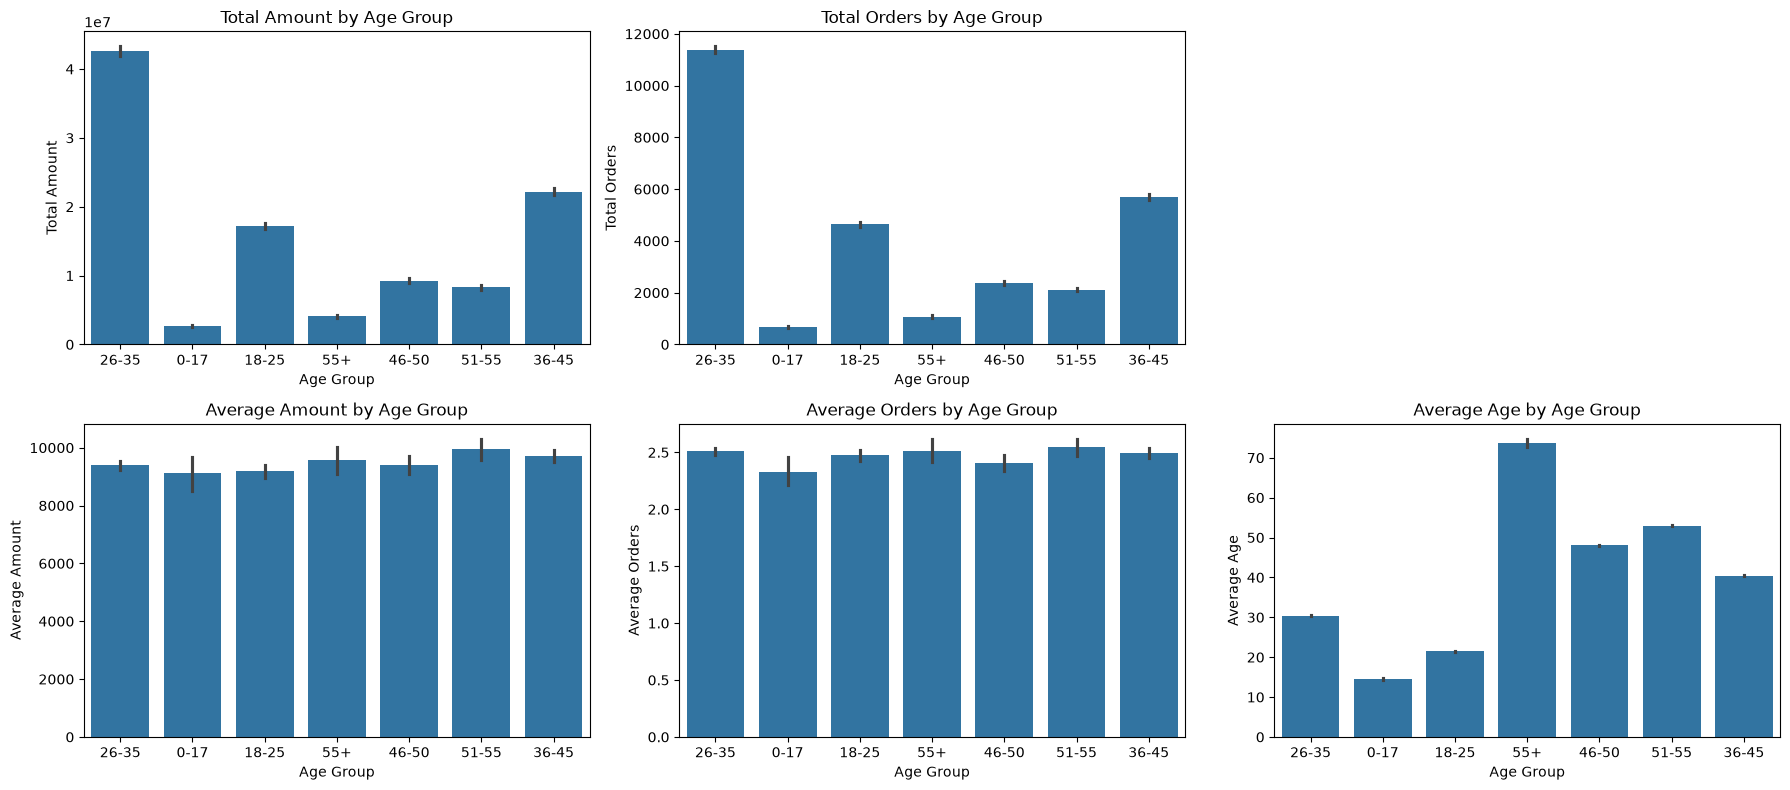

In [28]:
# Plot numerical columns by Age Group

sum_cols = [
    'Amount',
    'Orders'
]

mean_cols = [
    'Amount',
    'Orders',
    'Age'
]

fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 8)
)

# Total charts
for i, col in enumerate(sum_cols):

    sns.barplot(
        data=df_copy,
        x='Age Group',
        y=col,
        estimator='sum',
        ax=axes[0, i]
    )

    axes[0, i].set_title(f'Total {col} by Age Group')
    axes[0, i].set_xlabel('Age Group')
    axes[0, i].set_ylabel(f'Total {col}')


# Average charts
for i, col in enumerate(mean_cols):

    sns.barplot(
        data=df_copy,
        x='Age Group',
        y=col,
        estimator='mean',
        ax=axes[1, i]
    )

    axes[1, i].set_title(f'Average {col} by Age Group')
    axes[1, i].set_xlabel('Age Group')
    axes[1, i].set_ylabel(f'Average {col}')


# Remove the unused top-right subplot
fig.delaxes(axes[0, 2])

plt.tight_layout()
plt.show()

**Bivariate Analysis: Age Group vs Categorical Columns**

In [29]:
cat_cols_no_age_group = [
    'Occupation',
    'State',
    'Zone',
    'Product_Category'
]

for col in cat_cols_no_age_group:

    # Count
    age_group_cat = df_copy[['Age Group', col]].value_counts()

    # Percentage within each gender
    age_group_cat_pct = pd.crosstab(
        df_copy['Age Group'],
        df_copy[col],
        normalize='index'
    ).mul(100).round(2)

    print(f'{col} by Age Group:')
    print(age_group_cat)
    print()

    print(f'{col} percentage by Age Group:')
    print(age_group_cat_pct)
    print('=' * 50)

Occupation by Age Group:
Age Group  Occupation     
26-35      IT Sector          658
           Healthcare         571
           Aviation           551
           Banking            477
           Govt               319
36-45      IT Sector          315
           Healthcare         273
26-35      Hospitality        267
36-45      Aviation           263
26-35      Media              253
18-25      IT Sector          247
           Healthcare         225
36-45      Banking            224
26-35      Automobile         222
           Lawyer             220
           Retail             219
18-25      Aviation           216
26-35      Chemical           216
18-25      Banking            194
36-45      Govt               177
26-35      Construction       176
18-25      Govt               161
26-35      Food Processing    152
46-50      IT Sector          142
36-45      Chemical           139
26-35      Textile            136
36-45      Hospitality        135
46-50      Healthcare         

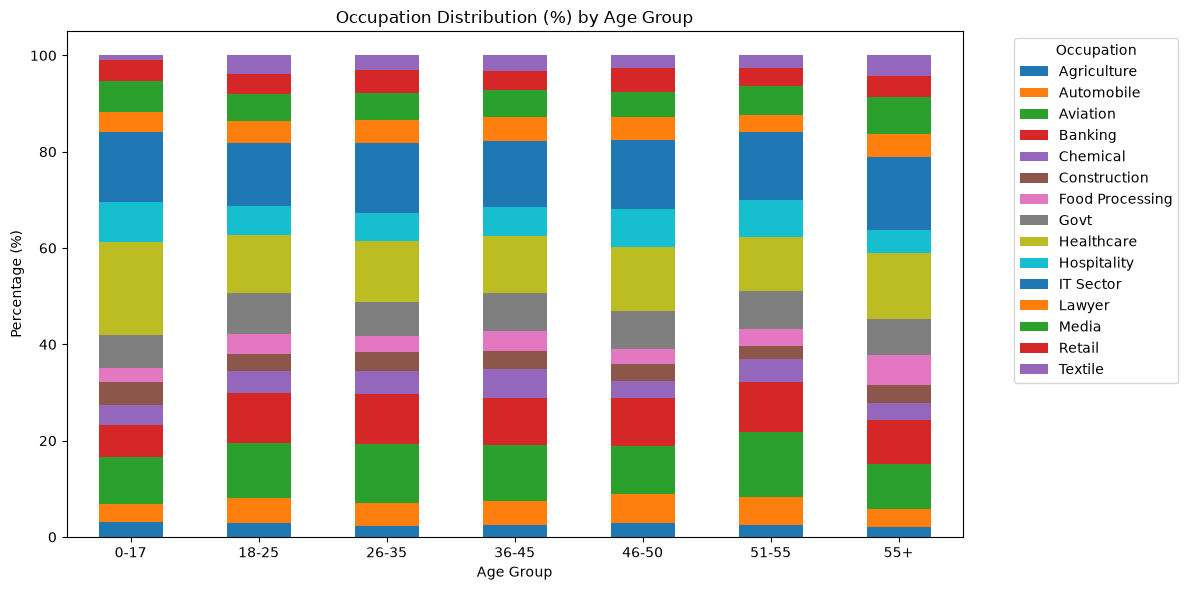

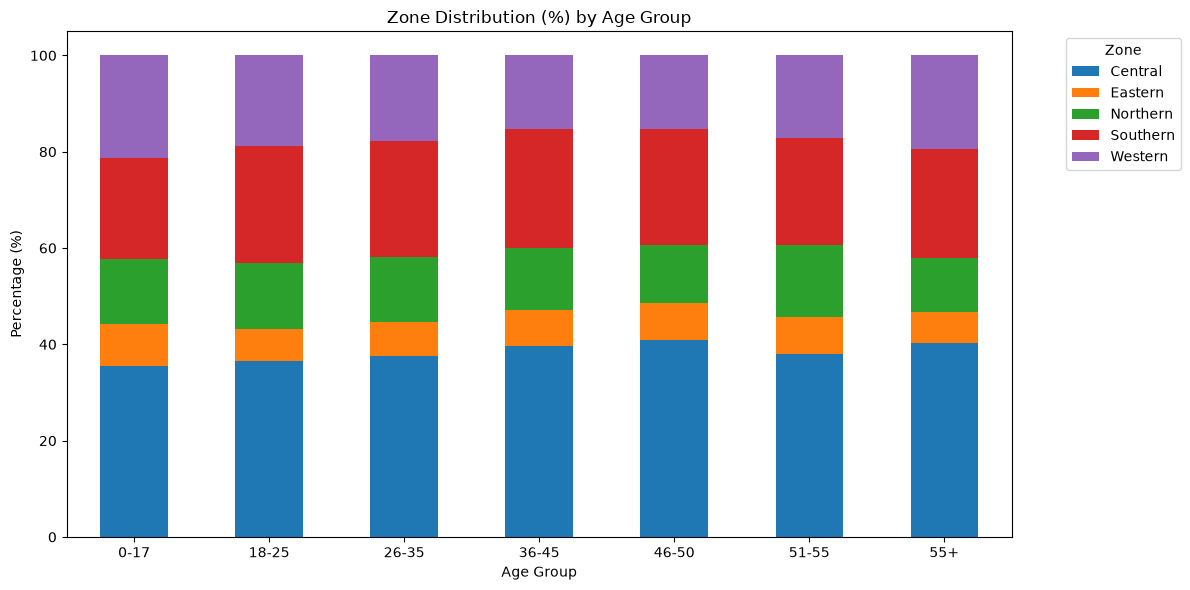

In [30]:
cat_cols_age_group_bar = [
    'Occupation',
    'Zone'
]

for col in cat_cols_age_group_bar:

    age_group_cat_pct = pd.crosstab(
        df_copy['Age Group'],
        df_copy[col],
        normalize='index'
    ).mul(100)

    ax = age_group_cat_pct.plot(
        kind='bar',
        stacked=True,
        figsize=(12, 6)
    )

    plt.title(f'{col} Distribution (%) by Age Group')
    plt.xlabel('Age Group')
    plt.ylabel('Percentage (%)')

    plt.legend(
        title=col,
        bbox_to_anchor=(1.05, 1),
        loc='upper left'
    )

    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

State      Andhra Pradesh  Bihar  Delhi  Gujarat  Haryana  Himachal Pradesh  \
Age Group                                                                     
0-17                 5.74   4.39   6.08     4.73     3.38              5.74   
18-25                7.56   3.78   7.99     3.73     4.53              5.11   
26-35                7.03   3.79  10.40     3.61     3.99              5.46   
36-45                7.48   3.72  11.55     3.72     3.41              5.56   
46-50                6.59   4.05  10.74     3.44     4.66              4.36   
51-55                7.70   4.21   8.42     4.81     4.45              6.14   
55+                  7.94   3.97   6.31     4.91     3.27              6.07   

State      Jharkhand  Karnataka  Kerala  Madhya Pradesh  Maharashtra  Punjab  \
Age Group                                                                      
0-17            4.39       8.11    6.42           10.14        16.55    2.03   
18-25           2.98      10.92    4.90         

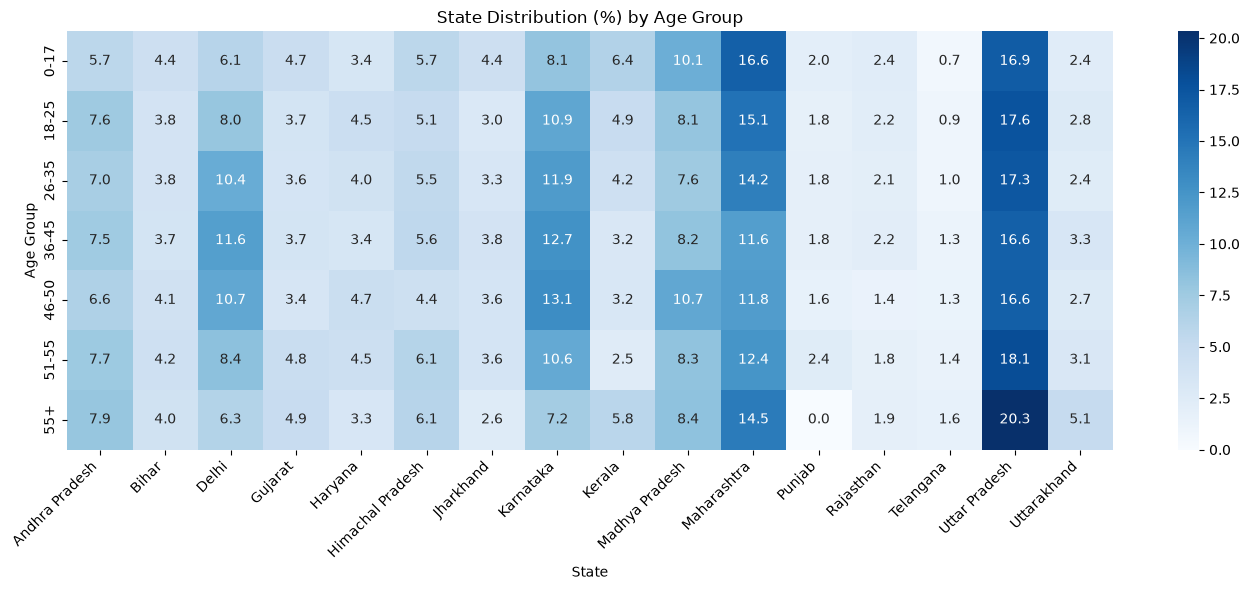

In [31]:
# percentage of customers within each age group who come from each state
state_age_group_pct = pd.crosstab(
    df_copy['Age Group'],
    df_copy['State'],
    normalize='index'
).mul(100)

print(state_age_group_pct, '\n')

plt.figure(figsize=(14, 6))

sns.heatmap(
    state_age_group_pct,
    annot=True,
    fmt='.1f',
    cmap='Blues'
)

plt.title('State Distribution (%) by Age Group')
plt.xlabel('State')
plt.ylabel('Age Group')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Product_Category  Auto  Beauty  Books  Clothing & Apparel  Decor  \
Age Group                                                          
0-17              1.01    3.04   0.34               24.32   0.34   
18-25             0.91    4.10   1.06               24.92   1.01   
26-35             0.95    3.61   0.90               23.27   0.73   
36-45             0.79    3.59   0.96               23.28   1.01   
46-50             0.61    3.34   0.91               23.71   1.01   
51-55             0.84    4.45   0.84               22.62   0.60   
55+               1.17    4.67   0.70               24.07   1.17   

Product_Category  Electronics & Gadgets  Food  Footwear & Shoes  Furniture  \
Age Group                                                                    
0-17                              20.61 28.04              2.03       4.39   
18-25                             18.26 25.45              2.40       3.62   
26-35                             18.25 21.86              9.34       3.02 

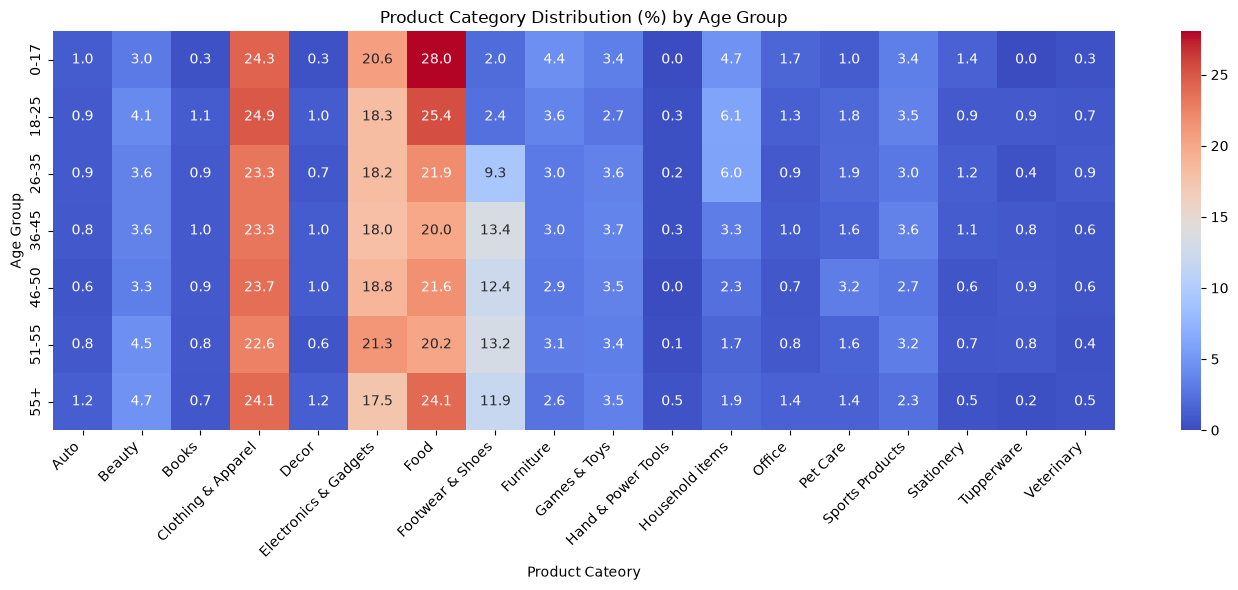

In [32]:
product_age_group_pct = pd.crosstab(
    df_copy['Age Group'],
    df_copy['Product_Category'],
    normalize='index'
).mul(100).round(2)

print(product_age_group_pct, '\n')

plt.figure(figsize=(14, 6))

sns.heatmap(
    product_age_group_pct,
    annot=True,
    fmt='.1f',
    cmap='coolwarm'
)

plt.title('Product Category Distribution (%) by Age Group')
plt.xlabel('Product Cateory')
plt.ylabel('Age Group')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Bivariate Analysis: Occupation vs Customer Name**

In [33]:
occupation_gender = (
    df_copy.groupby(['Occupation', 'Gender'])['Cust_name']
    .nunique()
    .unstack(fill_value=0)
)

occupation_gender['Total'] = occupation_gender.sum(axis=1)

occupation_gender = occupation_gender.sort_values(
    'Total',
    ascending=False
)

occupation_gender_pct = (
    occupation_gender[['F', 'M']]
    .div(occupation_gender['Total'], axis=0)
    .mul(100)
    .round(2)
)

print("Total Count of Occupation by Gender:")
print(occupation_gender, '\n')
print("=====" * 10)
print("\nPercentages of Occupation by Gender: ")
print(occupation_gender_pct)

Total Count of Occupation by Gender:
Gender             F    M  Total
Occupation                      
IT Sector        633  352    985
Healthcare       600  310    910
Aviation         589  279    868
Banking          547  236    783
Govt             436  192    628
Hospitality      360  180    540
Media            334  170    504
Automobile       289  145    434
Chemical         293  131    424
Lawyer           284  137    421
Retail           290  110    400
Food Processing  245  105    350
Construction     226  102    328
Textile          199   99    298
Agriculture      174   70    244 


Percentages of Occupation by Gender: 
Gender              F     M
Occupation                 
IT Sector       64.26 35.74
Healthcare      65.93 34.07
Aviation        67.86 32.14
Banking         69.86 30.14
Govt            69.43 30.57
Hospitality     66.67 33.33
Media           66.27 33.73
Automobile      66.59 33.41
Chemical        69.10 30.90
Lawyer          67.46 32.54
Retail          72.50 27.

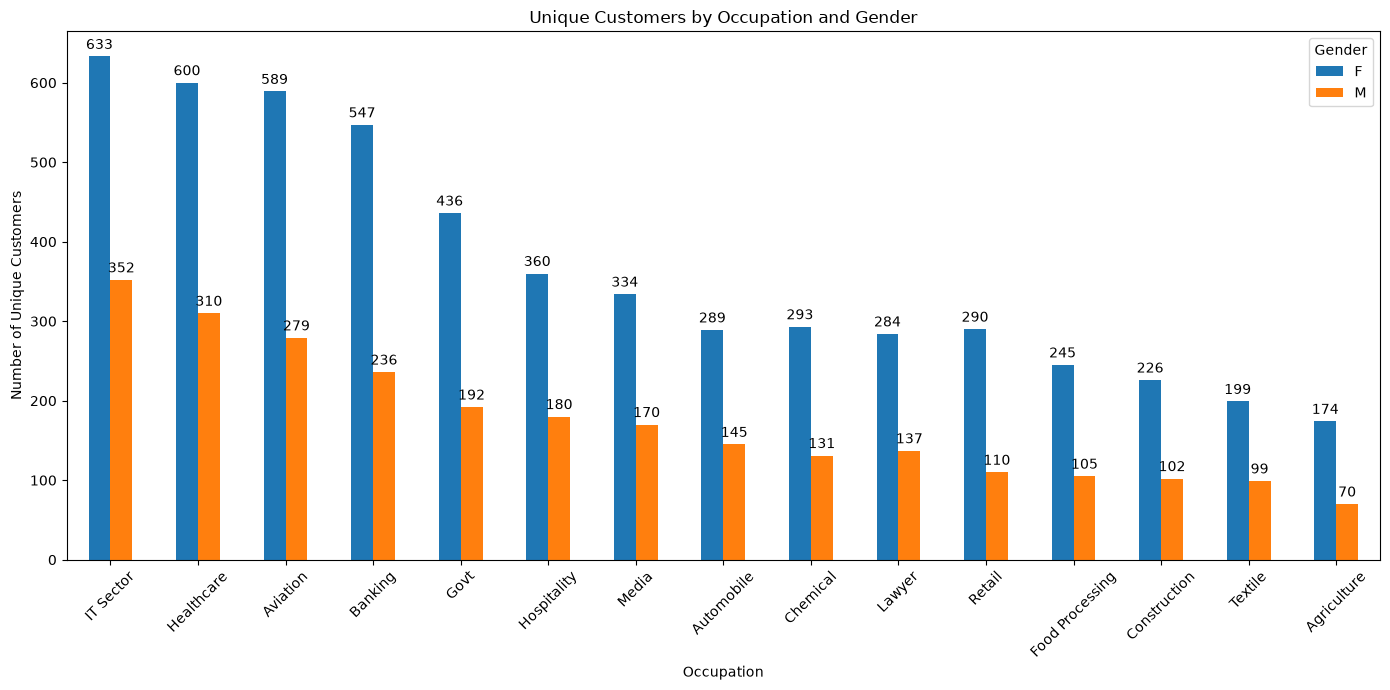

In [34]:
ax = occupation_gender[['F', 'M']].plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title('Unique Customers by Occupation and Gender')
plt.xlabel('Occupation')
plt.ylabel('Number of Unique Customers')
plt.legend(title='Gender')
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

**Bivariate Analysis: Zone vs Customer Name**

In [35]:
zone_gender = (
    df_copy.groupby(['Zone', 'Gender'])['Cust_name']
    .nunique()
    .unstack(fill_value=0)
)

zone_gender['Total'] = zone_gender.sum(axis=1)

zone_gender = zone_gender.sort_values(
    'Total',
    ascending=False
)

zone_gender_pct = (
    zone_gender[['F', 'M']]
    .div(zone_gender['Total'], axis=0)
    .mul(100)
    .round(2)
)

print("Unique Customer Count by Zone and Gender:")
print(zone_gender, '\n')
print("=====" * 10)
print("\nPercentages of Zone by Gender: ")
print(zone_gender_pct)

Unique Customer Count by Zone and Gender:
Gender       F    M  Total
Zone                      
Central   1076  686   1762
Southern   898  531   1429
Western    784  382   1166
Northern   632  345    977
Eastern    449  209    658 


Percentages of Zone by Gender: 
Gender       F     M
Zone                
Central  61.07 38.93
Southern 62.84 37.16
Western  67.24 32.76
Northern 64.69 35.31
Eastern  68.24 31.76


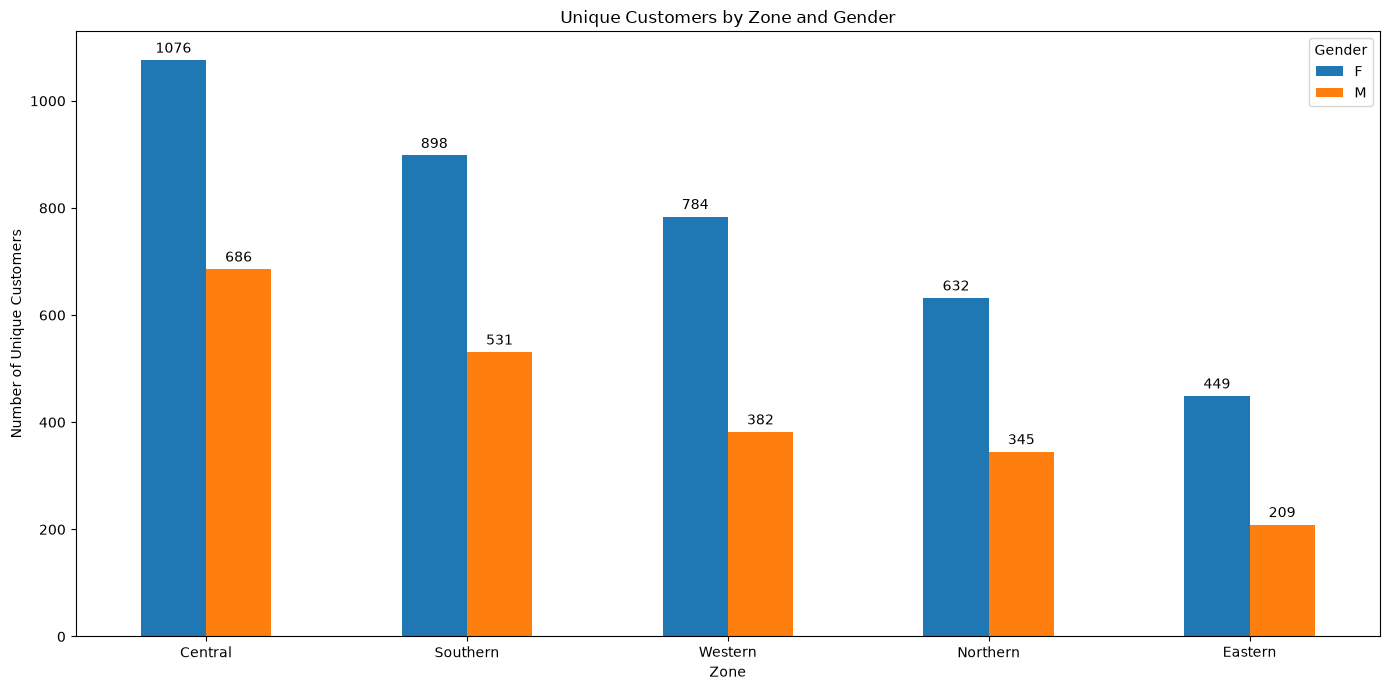

In [36]:
ax = zone_gender[['F', 'M']].plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title('Unique Customers by Zone and Gender')
plt.xlabel('Zone')
plt.ylabel('Number of Unique Customers')
plt.legend(title='Gender')
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

**Bivariate Analysis: State vs Customer Name**

In [37]:
state_gender = (
    df_copy.groupby(['State', 'Gender'])['Cust_name']
    .nunique()
    .unstack(fill_value=0)
)

state_gender['Total'] = state_gender.sum(axis=1)

state_gender = state_gender.sort_values(
    'Total',
    ascending=False
)

state_gender_pct = (
    state_gender[['F', 'M']]
    .div(state_gender['Total'], axis=0)
    .mul(100)
    .round(2)
)

print("Unique Customer Count by State and Gender:")
print(state_gender, '\n')
print("=====" * 10)
print("\nPercentages of State by Gender: ")
print(state_gender_pct)

Unique Customer Count by State and Gender:
Gender              F    M  Total
State                            
Uttar Pradesh     926  437   1363
Maharashtra       717  329   1046
Karnataka         629  320    949
Delhi             525  280    805
Madhya Pradesh    456  234    690
Andhra Pradesh    421  211    632
Himachal Pradesh  339  171    510
Haryana           277  118    395
Bihar             268  124    392
Kerala            265  123    388
Gujarat           267  111    378
Jharkhand         235  104    339
Uttarakhand       202   98    300
Rajasthan         136   75    211
Punjab            124   60    184
Telangana          74   46    120 


Percentages of State by Gender: 
Gender               F     M
State                       
Uttar Pradesh    67.94 32.06
Maharashtra      68.55 31.45
Karnataka        66.28 33.72
Delhi            65.22 34.78
Madhya Pradesh   66.09 33.91
Andhra Pradesh   66.61 33.39
Himachal Pradesh 66.47 33.53
Haryana          70.13 29.87
Bihar            68

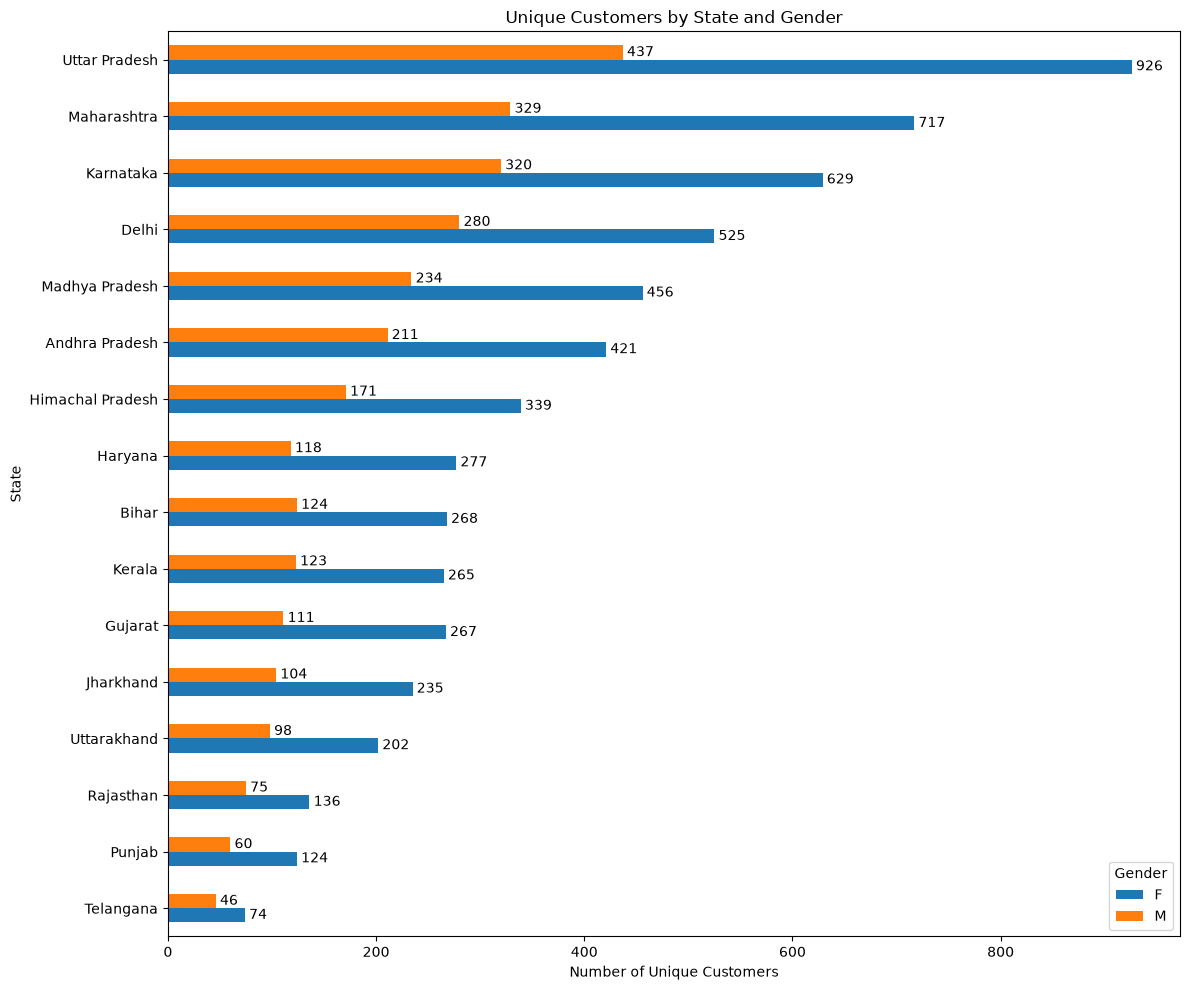

In [38]:
state_gender_sorted = state_gender.sort_values(
    'Total',
    ascending=True
)

ax = state_gender_sorted[['F', 'M']].plot(
    kind='barh',
    figsize=(12, 10)
)

plt.title('Unique Customers by State and Gender')
plt.xlabel('Number of Unique Customers')
plt.ylabel('State')
plt.legend(title='Gender')

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

**Bivariate Analysis: Product Category vs Amount**

Product Category Sales: 
Product_Category
Office                      81,936.00
Veterinary                 112,702.00
Hand & Power Tools         405,618.00
Pet Care                   482,277.00
Decor                      730,360.00
Books                    1,061,478.00
Tupperware               1,155,642.00
Household items          1,569,337.00
Stationery               1,676,051.50
Beauty                   1,959,484.00
Auto                     1,992,904.49
Sports Products          3,635,933.00
Games & Toys             4,331,694.00
Furniture                5,456,329.49
Electronics & Gadgets   15,607,657.00
Footwear & Shoes        15,656,654.45
Clothing & Apparel      16,484,472.00
Food                    33,979,579.50
Name: Amount, dtype: float64



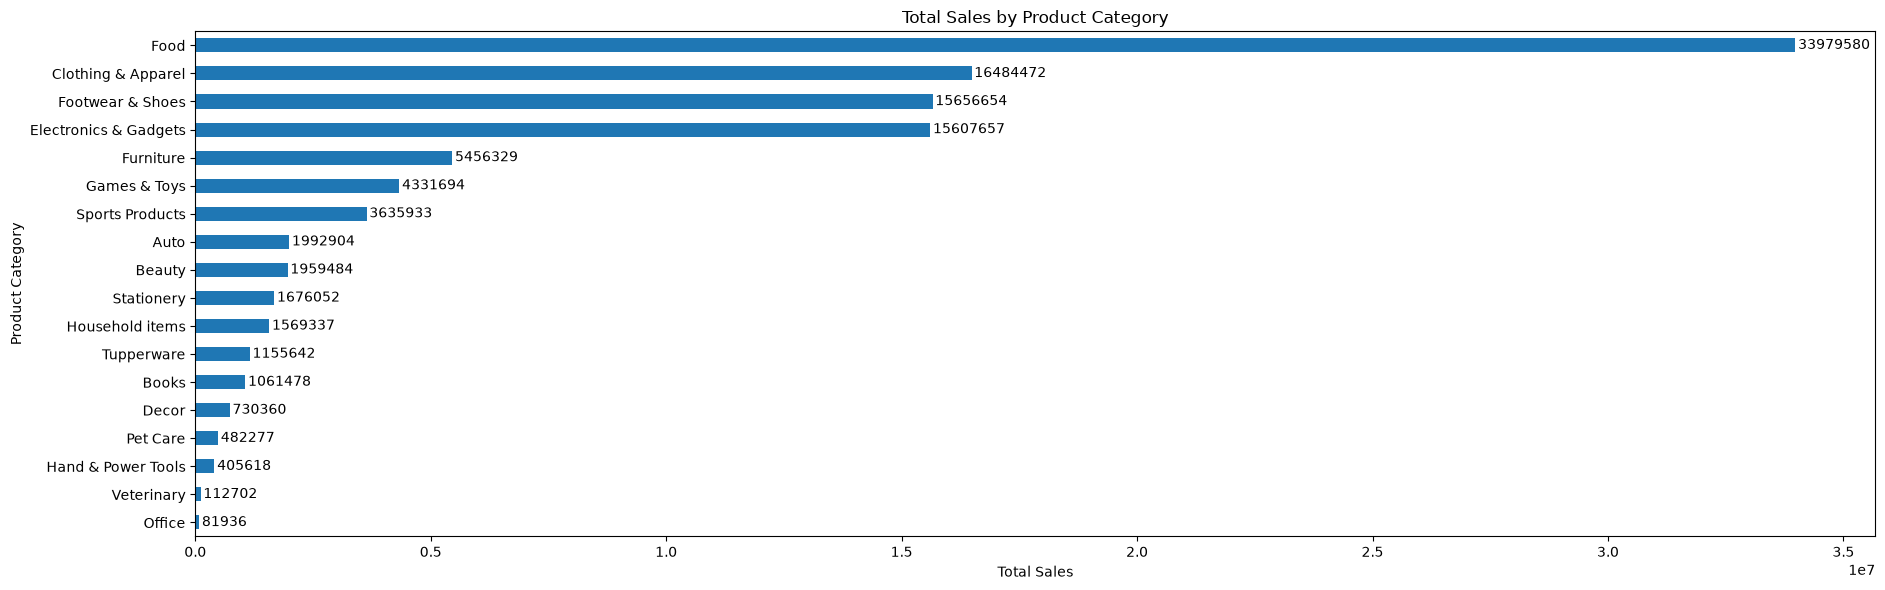

In [39]:
product_category_sales = (
    df_copy.groupby('Product_Category')['Amount']
    .sum()
    .sort_values(ascending=True)
)

print('Product Category Sales: ')
print(product_category_sales)
print()

ax = product_category_sales.plot(
    kind='barh',
    figsize=(19,6)

)

plt.title('Total Sales by Product Category')
plt.xlabel('Total Sales')
plt.ylabel('Product Category')

for container in ax.containers:
  ax.bar_label(
      container,
      fmt='%.0f',
      padding=2
  )


plt.tight_layout()
plt.show()

**Bivariate Analysis: Occupation vs Amount**

Average Purchase Amount by Occupation:
Occupation
Govt              9,973.32
Media             9,883.57
Chemical          9,803.90
Aviation          9,625.66
Food Processing   9,623.33
Retail            9,547.25
Automobile        9,512.06
Banking           9,484.80
Lawyer            9,381.67
IT Sector         9,349.46
Healthcare        9,257.52
Textile           9,203.60
Agriculture       9,166.66
Hospitality       9,077.14
Construction      8,691.50
Name: Amount, dtype: float64



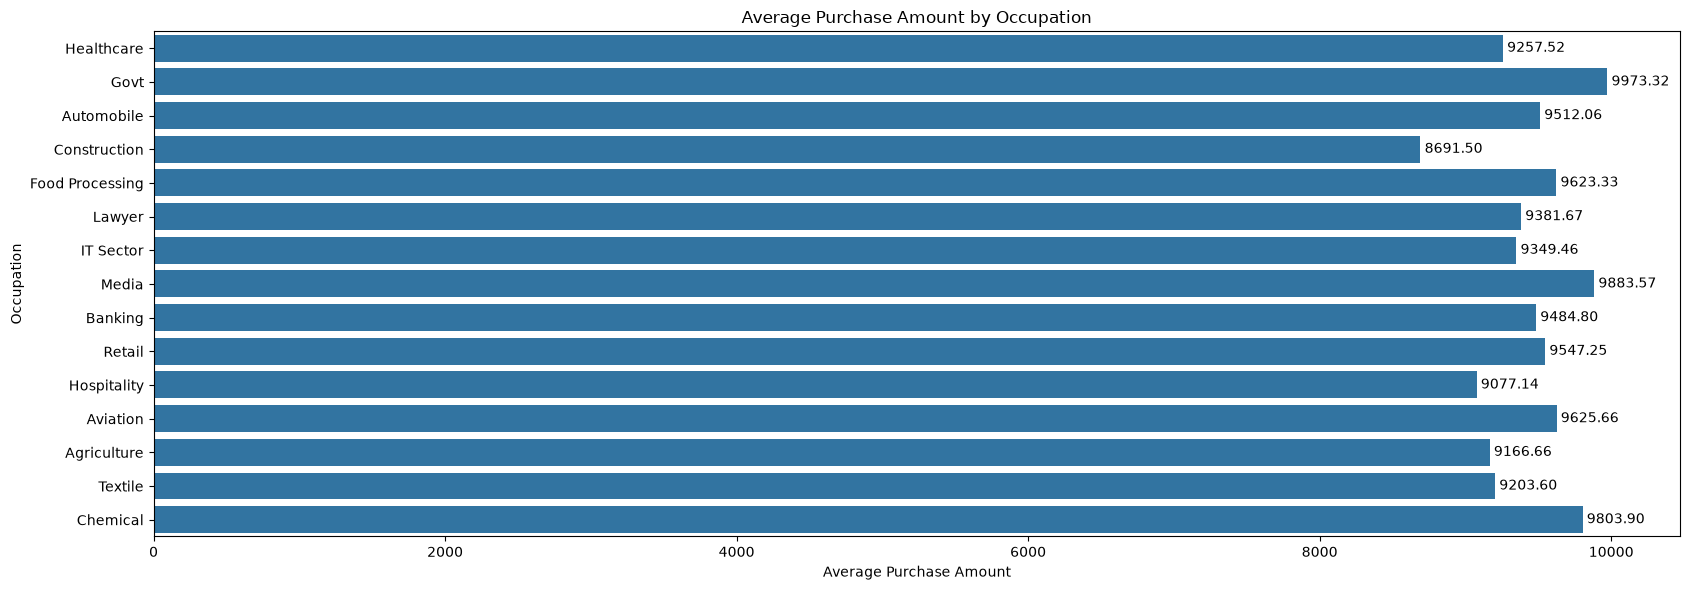

In [40]:
occupation_amount = (
    df_copy.groupby('Occupation')['Amount']
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print('Average Purchase Amount by Occupation:')
print(occupation_amount)
print()

plt.figure(figsize=(17, 6))

ax = sns.barplot(
    data=df_copy,
    x='Amount',
    y='Occupation',
    estimator='mean',
    errorbar=None
)

plt.title('Average Purchase Amount by Occupation')
plt.xlabel('Average Purchase Amount')
plt.ylabel('Occupation')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

**Customer Segmentation Analysis**

In [41]:
segment_cols = [
    'Age Group',
    'Occupation',
    'Zone',
    'Marital_Status'
]

for col in segment_cols:

    segment_sales = (
        df_copy.groupby(col)['Amount']
        .sum()
        .sort_values(ascending=False)
    )

    print(f'Total Sales by {col}:')
    print(segment_sales.round(2))
    print('=' * 50)

Total Sales by Age Group:
Age Group
26-35   42,613,278.44
36-45   22,181,889.49
18-25   17,235,530.00
46-50    9,278,997.00
51-55    8,270,487.00
55+      4,100,274.50
0-17     2,699,653.00
Name: Amount, dtype: float64
Total Sales by Occupation:
Occupation
IT Sector         14,828,247.00
Healthcare        13,034,587.49
Aviation          12,599,994.00
Banking           10,803,188.95
Govt               8,517,212.00
Hospitality        6,372,152.50
Media              6,295,832.99
Automobile         5,383,828.00
Chemical           5,313,713.50
Lawyer             4,981,665.00
Retail             4,783,170.00
Food Processing    4,070,670.00
Construction       3,589,588.00
Textile            3,221,261.00
Agriculture        2,584,999.00
Name: Amount, dtype: float64
Total Sales by Zone:
Zone
Central    41,685,810.95
Southern   26,642,245.48
Western    18,394,480.00
Northern   12,616,448.00
Eastern     7,041,125.00
Name: Amount, dtype: float64
Total Sales by Marital_Status:
Marital_Status
0   62,1

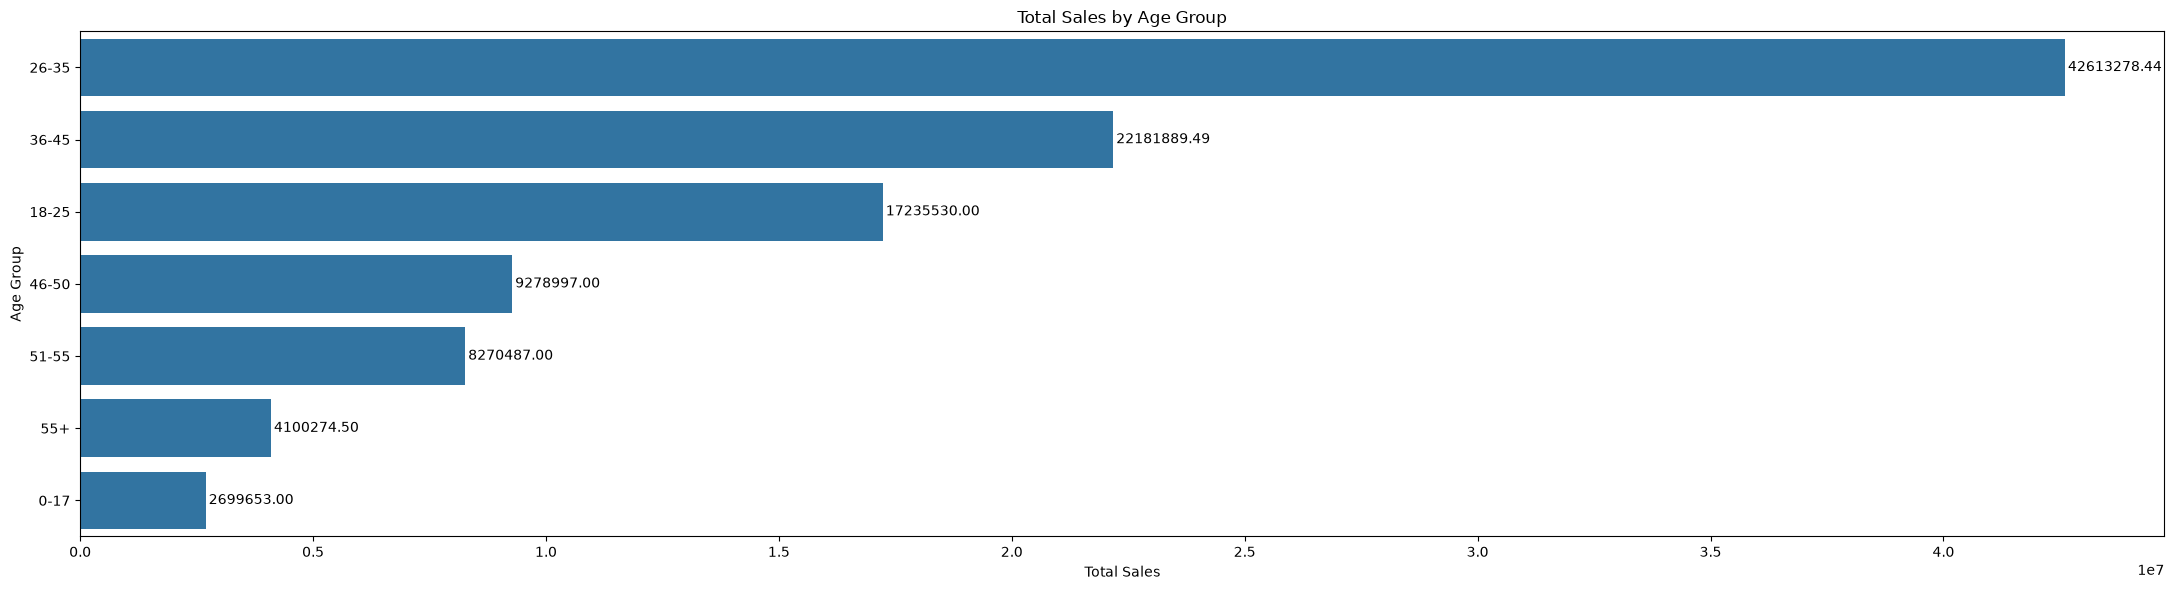

In [42]:
segment_sales = (
    df_copy.groupby('Age Group')['Amount']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(22, 6))

ax = sns.barplot(
    x=segment_sales.values,
    y=segment_sales.index,
    errorbar=None
)

plt.title('Total Sales by Age Group')
plt.xlabel('Total Sales')
plt.ylabel('Age Group')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=2)

plt.tight_layout()
plt.show()

**Correlation Analysis**

,User_ID,Age,Marital_Status,Orders,Amount
User_ID,1.00,0.02,0.00,-0.02,-0.01
Age,0.02,1.00,-0.01,0.01,0.03
Marital_Status,0.00,-0.01,1.00,-0.00,-0.02
Orders,-0.02,0.01,-0.00,1.00,-0.01
Amount,-0.01,0.03,-0.02,-0.01,1.00


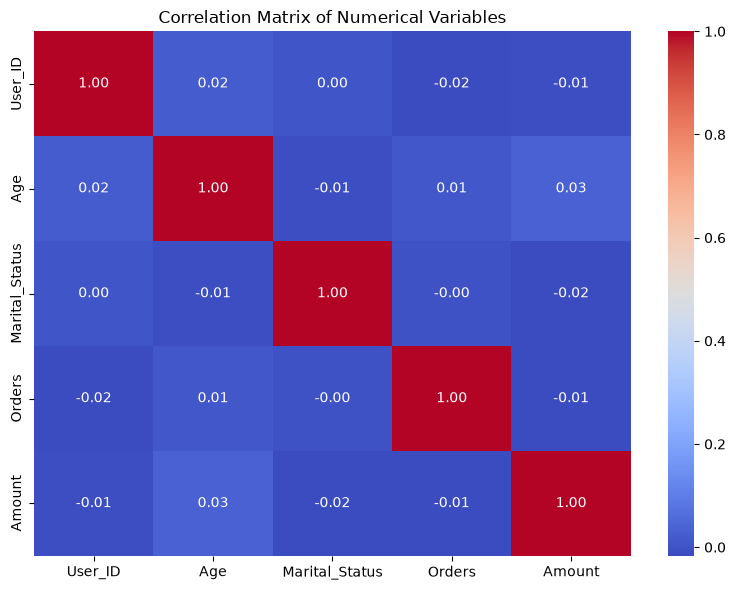

In [43]:
num_cols_corr_matrix = df_copy.select_dtypes(include='number').corr()
display(num_cols_corr_matrix)
print('\n')

plt.figure(figsize=(8, 6))

sns.heatmap(
    num_cols_corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

**Business Recommendations**

Based on the analysis, the company could prioritize the **26–35 age group**, which represents the largest share of customers and generates the highest total sales. Marketing strategies could focus on this segment while considering its purchasing patterns and product preferences.

The company could also consider targeted campaigns for **Food** and **Clothing & Apparel**, which are among the strongest-performing product categories. Since product preferences vary across age groups, campaigns could be tailored to different customer segments rather than applying the same product strategy across all age groups.

Finally, the differences observed across **occupation, geographic zone, and marital status** could be used to further segment customers and identify opportunities for more personalized marketing and sales initiatives.


 **Conclusion**

The analysis provides an overview of the customer profile, sales performance, purchasing behavior, and product preferences within the dataset.

The customer base is predominantly **female**, with the **26–35 age group** representing the largest share of customers at **40.36%**. Unmarried customers also account for a larger share of the dataset than married customers. In terms of occupation, **IT Sector, Healthcare, and Aviation** have the highest customer counts. Geographically, customers are concentrated primarily in the **Central Zone**, with **Uttar Pradesh** having the highest number of customers among the states analyzed.

From a sales perspective, the **26–35 age group** contributes the highest total sales, followed by the **36–45 age group**. Among product categories, **Food** generates the highest total sales, followed by **Clothing & Apparel, Footwear & Shoes, and Electronics & Gadgets**. The distribution of transaction amounts is slightly right-skewed, indicating that most transaction values are concentrated toward the lower and middle ranges, with some higher-value purchases.

Purchasing behavior also varies across customer segments. The **26–35 age group** places the highest number of orders and contributes the highest total sales. By occupation, **Government, Media, and Chemical** have the highest average purchase amounts, while the **IT Sector** generates the highest total sales among occupations. The **Central Zone** also contributes the highest total sales among geographic segments, while unmarried customers account for a larger share of total sales than married customers.

Product preferences show some variation across age groups. **Food** has the highest representation among customers aged **0–17 and 18–25**, while **Clothing & Apparel** has the highest representation among customers aged **26 and above**. This suggests that product-category preferences differ across age groups and may provide opportunities for more targeted marketing strategies.

Overall, the analysis indicates that the **26–35 age group is a major customer and sales segment**, while **Food and Clothing & Apparel** are important product categories. The findings also highlight differences in customer behavior across occupations, geographic zones, marital status, and age groups. These patterns can be used as a basis for developing more targeted marketing and sales strategies.
